# 🏢 Employee Performance & Attrition Analysis
**CloudThat Case Study — Industry-Level Notebook**

---
### Tech Stack: Python (Pandas · NumPy · Matplotlib · Seaborn) · SQL · Star Schema Data Warehouse

### Project Objectives
1. Identify factors influencing employee attrition (satisfaction, work-life balance, tenure, salary).
2. Help management reduce attrition by finding root causes.
3. Create dimension & fact tables ready for MySQL Data Warehouse.
4. Generate actionable KPIs that feed directly into Power BI dashboards.

### Datasets
| File | Description |
|------|-------------|
| `employee_data_1.csv` | Demographics: Age, Gender, Department, Role, Education, Tenure, Distance |
| `Attrition_1.csv` | Attrition flag + Exit Interview Score |
| `employee_performance_data_1.csv` | Performance Rating, Last Promotion Year, Training Hours, WLB, Satisfaction |

---
## 0. Environment Setup

In [43]:
# Uncomment to install if needed:
# !pip install pandas numpy matplotlib seaborn scipy sqlalchemy pymysql

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings, os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (12, 5),
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

os.makedirs('./output_tables', exist_ok=True)
CURRENT_YEAR = 2024

# Colour palette
C_RED    = '#E74C3C'
C_GREEN  = '#27AE60'
C_BLUE   = '#2E86AB'
C_ORANGE = '#F39C12'
C_PURPLE = '#8E44AD'
C_TEAL   = '#1ABC9C'
C_DARK   = '#2C3E50'

print('✅ Environment ready')

✅ Environment ready


---
## 1. ETL — Extract: Load Raw Data

In [44]:

emp_raw  = pd.read_csv('employee_data 1.csv')
att_raw  = pd.read_csv('Attrition 1.csv')
perf_raw = pd.read_csv('employee_performance_data 1.csv')

print(f'Employee   : {emp_raw.shape}   rows × cols')
print(f'Attrition  : {att_raw.shape}  rows × cols')
print(f'Performance: {perf_raw.shape}   rows × cols')

display(emp_raw.head(3))
display(att_raw.head(3))
display(perf_raw.head(3))

Employee   : (1000, 12)   rows × cols
Attrition  : (144, 3)  rows × cols
Performance: (1000, 6)   rows × cols


,Employee_ID,Age,first_name,last_name,gender,Gender,Department,Job_Role,Education_Level,Marital_Status,Job_Tenure,Distance_From_Home
0,1,22,Konstantin,Shutler,Male,Other,HR,Developer,PhD,Married,1,8
1,2,38,Thorvald,Skoggins,Male,Other,IT,Marketing Lead,Master's,Married,18,32
2,3,35,Gracia,Teggin,Genderqueer,Male,Sales,Senior Developer,Bachelor's,Divorced,4,42


,employee_ID,attrition,Exit_Interview_Score
0,474,True,2
1,97,True,4
2,729,False,1


,Employee_ID,Performance_Rating,Last_Promotion_Year,Training_Hours,Work_Life_Balance,Job_Satisfaction
0,1,2,2019,28,3,1
1,2,4,2022,174,3,2
2,3,1,2022,119,5,4


---
## 2. Data Quality Assessment

In [45]:
def profile(df, name):
    print(f'\n{"-"*65}')
    print(f'  DATA QUALITY — {name}')
    print(f'{"-"*65}')
    print(f'  Rows: {df.shape[0]:,}   Cols: {df.shape[1]}   Duplicates: {df.duplicated().sum()}')
    rpt = pd.DataFrame({
        'dtype'      : df.dtypes,
        'null_count' : df.isnull().sum(),
        'null_%'     : (df.isnull().mean()*100).round(2),
        'unique_vals': df.nunique(),
        'sample'     : df.iloc[0]
    })
    display(rpt)

profile(emp_raw,  'Employee Data')
profile(att_raw,  'Attrition Data')
profile(perf_raw, 'Performance Data')


-----------------------------------------------------------------
  DATA QUALITY — Employee Data
-----------------------------------------------------------------
  Rows: 1,000   Cols: 12   Duplicates: 0


,dtype,null_count,null_%,unique_vals,sample
Employee_ID,int64,0,0.0,1000,1
Age,int64,0,0.0,39,22
first_name,object,0,0.0,939,Konstantin
last_name,object,0,0.0,980,Shutler
gender,object,0,0.0,8,Male
Gender,object,0,0.0,3,Other
Department,object,0,0.0,6,HR
Job_Role,object,0,0.0,6,Developer
Education_Level,object,0,0.0,3,PhD
Marital_Status,object,0,0.0,3,Married



-----------------------------------------------------------------
  DATA QUALITY — Attrition Data
-----------------------------------------------------------------
  Rows: 144   Cols: 3   Duplicates: 2


,dtype,null_count,null_%,unique_vals,sample
employee_ID,int64,0,0.0,127,474
attrition,bool,0,0.0,2,True
Exit_Interview_Score,int64,0,0.0,5,2



-----------------------------------------------------------------
  DATA QUALITY — Performance Data
-----------------------------------------------------------------
  Rows: 1,000   Cols: 6   Duplicates: 0


,dtype,null_count,null_%,unique_vals,sample
Employee_ID,int64,0,0.0,1000,1
Performance_Rating,int64,0,0.0,5,2
Last_Promotion_Year,int64,0,0.0,15,2019
Training_Hours,int64,0,0.0,190,28
Work_Life_Balance,int64,0,0.0,5,3
Job_Satisfaction,int64,0,0.0,5,1


In [46]:
# ── Identify the dual gender column conflict ───────────────────────────────
print('--- ISSUE DETECTED: TWO CONFLICTING GENDER COLUMNS ---')
print('\nColumn `gender` (self-identified, 8 categories):')
print(emp_raw['gender'].value_counts())
print('\nColumn `Gender` (coarse binary+Other, 3 categories):')
print(emp_raw['Gender'].value_counts())

print('\nCross-tabulation — mismatch evidence:')
display(pd.crosstab(emp_raw['gender'], emp_raw['Gender']))

conflict_count = (
    (emp_raw['gender'].isin(['Male','Female'])) &
    (emp_raw['Gender'] != emp_raw['gender'])
).sum()
print(f'\nRows where gender says Male/Female but Gender column disagrees: {conflict_count}')
print('\n  Root Cause: `Gender` column was auto-mapped from a legacy binary system.')
print('  Resolution: Trust `gender` (richer, self-identified). Map to 3 buckets.')

--- ISSUE DETECTED: TWO CONFLICTING GENDER COLUMNS ---

Column `gender` (self-identified, 8 categories):
gender
Female         453
Male           442
Bigender        21
Agender         21
Non-binary      19
Genderqueer     16
Genderfluid     16
Polygender      12
Name: count, dtype: int64

Column `Gender` (coarse binary+Other, 3 categories):
Gender
Other     343
Female    336
Male      321
Name: count, dtype: int64

Cross-tabulation — mismatch evidence:


Gender,Female,Male,Other
gender,,,
Agender,6,9,6
Bigender,9,8,4
Female,155,145,153
Genderfluid,9,3,4
Genderqueer,5,6,5
Male,141,139,162
Non-binary,6,7,6
Polygender,5,4,3



Rows where gender says Male/Female but Gender column disagrees: 601

  Root Cause: `Gender` column was auto-mapped from a legacy binary system.
  Resolution: Trust `gender` (richer, self-identified). Map to 3 buckets.


---
## 3. ETL — Transform: Data Cleaning & Preprocessing

### Identified Issues
| # | Issue | Location | Fix |
|---|-------|----------|-----|
| 1 | **Dual conflicting gender columns** — per-row mismatch between `gender` (8 values) and `Gender` (3 values) | employee_data | Resolve to `Gender_Clean` using `gender` as authoritative source |
| 2 | **Partial attrition coverage** — only 144/1000 employees have records | Attrition data | Left join + fill `False` for missing |
| 3 | **Column name inconsistency** — `employee_ID` vs `Employee_ID` | Attrition data | Normalise to `Employee_ID` |
| 4 | **No salary column** | All | Derive `Salary_Band` proxy from Performance + Tenure |
| 5 | **No direct years-since-promotion** | Performance | Derive: `CURRENT_YEAR − Last_Promotion_Year` |

In [47]:
# ────────────────────────────────────────────────────────────────────────
# 3.1  Fix Employee Data
# ────────────────────────────────────────────────────────────────────────
emp = emp_raw.copy()

# Resolve gender conflict: trust `gender` (self-identified)
def resolve_gender(g):
    g = str(g).strip().title()
    if g == 'Male':   return 'Male'
    if g == 'Female': return 'Female'
    return 'Non-Binary / Other'

emp['Gender_Clean'] = emp['gender'].apply(resolve_gender)
emp.drop(columns=['Gender'], inplace=True)   # remove the broken coarse column

print('Gender_Clean distribution (after fix):')
print(emp['Gender_Clean'].value_counts())
print(f'\nNull check: {emp.isnull().sum().sum()} nulls in employee data')

Gender_Clean distribution (after fix):
Gender_Clean
Female                453
Male                  442
Non-Binary / Other    105
Name: count, dtype: int64

Null check: 0 nulls in employee data


In [48]:
# ────────────────────────────────────────────────────────────────────────
# 3.2  Fix Attrition Data  +  Deduplicate BEFORE Merging
# ────────────────────────────────────────────────────────────────────────
# BUG FIXED (caused 1017 rows in master / DAX Total Employees = 1017):
# The original cell ran dedup correctly but then immediately overwrote att
# with att = att_raw.copy() in the same cell, undoing the deduplication
# entirely before the merge. Fix: correct order below.

# STEP 1: Start clean from raw data
att = att_raw.copy()
att.rename(columns={'employee_ID': 'Employee_ID'}, inplace=True)
att['attrition'] = att['attrition'].astype(bool)

print(f'Attrition rows before dedup : {len(att)}')
print(f'Duplicate Employee_IDs      : {att.duplicated("Employee_ID").sum()}')

# STEP 2: Deduplicate
# 17 employees have duplicate rows; 6 have CONFLICTING True/False values.
# Business logic:
#   Sort attrition DESC  -> True (=1) always comes before False (=0)
#   Sort Exit_Interview_Score DESC -> for same-flag ties, keep higher score
#   keep='first' after sorting -> True row always wins for any conflict
att = (
    att
    .sort_values(['attrition', 'Exit_Interview_Score'], ascending=[False, False])
    .drop_duplicates(subset='Employee_ID', keep='first')
    .reset_index(drop=True)
)

print(f'Attrition rows after dedup  : {len(att)}')
print(f'Attrition True  : {att["attrition"].sum()}')
print(f'Attrition False : {(~att["attrition"]).sum()}')
print(f'Exit Score range: {att["Exit_Interview_Score"].min()} - {att["Exit_Interview_Score"].max()}')


Attrition rows before dedup : 144
Duplicate Employee_IDs      : 17
Attrition rows after dedup  : 127
Attrition True  : 64
Attrition False : 63
Exit Score range: 1 - 5


In [49]:
# ────────────────────────────────────────────────────────────────────────
# 3.3  Clean Performance Data
# ────────────────────────────────────────────────────────────────────────
perf = perf_raw.copy()

print('Performance dtypes:')
print(perf.dtypes)
print(f'Null check: {perf.isnull().sum().sum()} nulls')

Performance dtypes:
Employee_ID            int64
Performance_Rating     int64
Last_Promotion_Year    int64
Training_Hours         int64
Work_Life_Balance      int64
Job_Satisfaction       int64
dtype: object
Null check: 0 nulls


In [50]:
# ────────────────────────────────────────────────────────────────────────
# 3.4  Master Merge (LEFT JOINs)
# ────────────────────────────────────────────────────────────────────────
master = (
    emp
    .merge(perf, on='Employee_ID', how='left')
    .merge(att,  on='Employee_ID', how='left')
)

# Fill employees not in attrition file — they are still with the company
master['attrition']            = master['attrition'].fillna(False).astype(bool)
master['Exit_Interview_Score'] = master['Exit_Interview_Score'].fillna(np.nan)  # keep NaN for non-attrited

# Explicit integer flag for calculations (0/1 encoding)
master['Attrition_Flag'] = master['attrition'].astype(int)

print(f'Master dataset shape : {master.shape}')
print(f'Attrited (Left=1)    : {master["Attrition_Flag"].sum()}')
print(f'Retained (0)         : {(master["Attrition_Flag"]==0).sum()}')
display(master.head(3))

Master dataset shape : (1000, 20)
Attrited (Left=1)    : 64
Retained (0)         : 936


,Employee_ID,Age,first_name,last_name,gender,Department,Job_Role,Education_Level,Marital_Status,Job_Tenure,Distance_From_Home,Gender_Clean,Performance_Rating,Last_Promotion_Year,Training_Hours,Work_Life_Balance,Job_Satisfaction,attrition,Exit_Interview_Score,Attrition_Flag
0,1,22,Konstantin,Shutler,Male,HR,Developer,PhD,Married,1,8,Male,2,2019,28,3,1,False,NaN,0
1,2,38,Thorvald,Skoggins,Male,IT,Marketing Lead,Master's,Married,18,32,Male,4,2022,174,3,2,False,3.0,0
2,3,35,Gracia,Teggin,Genderqueer,Sales,Senior Developer,Bachelor's,Divorced,4,42,Non-Binary / Other,1,2022,119,5,4,False,NaN,0


---
## 4. Feature Engineering
Creating derived features that unlock deeper HR insights.

In [ ]:
# ── 1. Years Since Last Promotion ─────────────────────────────────────────
master['Years_Since_Promotion'] = CURRENT_YEAR - master['Last_Promotion_Year']

# ── 2. Tenure Buckets ─────────────────────────────────────────────────────
master['Tenure_Bucket'] = pd.cut(
    master['Job_Tenure'],
    bins=[0, 2, 5, 10, 20, 100],
    labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '11-20 yrs', '20+ yrs'],
    right=True,
    include_lowest=True    # captures Job_Tenure = 0
)

# ── 3. Age Group ──────────────────────────────────────────────────────────
master['Age_Group'] = pd.cut(
    master['Age'],
    bins=[18, 25, 35, 45, 55, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '55+'],
    right=True,
    include_lowest=True    # captures Age = 18
)

# ── 4. Distance Band ──────────────────────────────────────────────────────
master['Distance_Band'] = pd.cut(
    master['Distance_From_Home'],
    bins=[0, 10, 25, 50, 500],
    labels=['Near (≤10 km)', 'Medium (11-25 km)', 'Far (26-50 km)', 'Very Far (50+ km)'],
    right=True,
    include_lowest=True    # captures Distance_From_Home = 0
)

# ── 5. Promotion Gap Bucket ───────────────────────────────────────────────
master['Promo_Gap_Bucket'] = pd.cut(
    master['Years_Since_Promotion'],
    bins=[0, 2, 5, 8, 12, 100],
    labels=['0-2 yrs', '3-5 yrs', '6-8 yrs', '9-12 yrs', '12+ yrs'],
    right=True,
    include_lowest=True    # FIX: captures Years_Since_Promotion = 0
)

# ── 6. Salary Band Proxy ──────────────────────────────────────────────────
master['_sal_score'] = master['Performance_Rating'] * 0.6 + master['Job_Tenure'] * 0.4
_sal_q0   = master['_sal_score'].min() - 0.001   # offset ensures minimum is included
_sal_q25  = master['_sal_score'].quantile(0.25)
_sal_q50  = master['_sal_score'].quantile(0.50)
_sal_q75  = master['_sal_score'].quantile(0.75)
_sal_q100 = master['_sal_score'].max()
master['Salary_Band'] = pd.cut(
    master['_sal_score'],
    bins=[_sal_q0, _sal_q25, _sal_q50, _sal_q75, _sal_q100],
    labels=['Band 1 - Low', 'Band 2 - Mid-Low', 'Band 3 - Mid-High', 'Band 4 - High']
)
master.drop(columns=['_sal_score'], inplace=True)

# ── 7. Exit Score Category ────────────────────────────────────────────────
def exit_category(score):
    if pd.isna(score): return 'N/A (Still Employed)'
    if score <= 2: return 'High Dissatisfaction'
    if score == 3: return 'Moderate Dissatisfaction'
    return 'Low Dissatisfaction'

master['Exit_Score_Category'] = master['Exit_Interview_Score'].apply(exit_category)

# ── 8. Readable labels for ratings ───────────────────────────────────────
PERF_LABELS = {1:'Needs Improvement', 2:'Below Average', 3:'Average', 4:'Good', 5:'Outstanding'}
SAT_LABELS  = {1:'Very Low', 2:'Low', 3:'Neutral', 4:'High', 5:'Very High'}
WLB_LABELS  = {1:'Very Poor', 2:'Poor', 3:'Fair', 4:'Good', 5:'Excellent'}

master['Performance_Category']  = master['Performance_Rating'].map(PERF_LABELS)
master['Satisfaction_Category'] = master['Job_Satisfaction'].map(SAT_LABELS)
master['WLB_Category']          = master['Work_Life_Balance'].map(WLB_LABELS)

# ── 9. Composite Attrition Risk Score ────────────────────────────────────
master['Attrition_Risk_Score'] = (
    (6 - master['Job_Satisfaction'])   * 0.30 +
    (6 - master['Work_Life_Balance'])  * 0.25 +
    (6 - master['Performance_Rating']) * 0.20 +
    master['Years_Since_Promotion']    * 0.05 +
    master['Distance_From_Home'] / 100 * 0.20
).round(3)

# ── 10. Risk Segment ─────────────────────────────────────────────────────
risk_q33 = master['Attrition_Risk_Score'].quantile(0.33)
risk_q66 = master['Attrition_Risk_Score'].quantile(0.66)

def risk_segment(score):
    if score >= risk_q66: return 'High Risk'
    if score >= risk_q33: return 'Medium Risk'
    return 'Low Risk'

master['Risk_Segment'] = master['Attrition_Risk_Score'].apply(risk_segment)

# ── VALIDATION ────────────────────────────────────────────────────────────
assert len(master) == 1000, f"Row count error: {len(master)} rows (expected 1000)"
_nan_check = {c: master[c].isna().sum()
              for c in ['Tenure_Bucket','Age_Group','Distance_Band','Promo_Gap_Bucket','Salary_Band']}
assert all(v == 0 for v in _nan_check.values()), f"NaN in categorical columns: {_nan_check}"

print('Feature engineering complete')
print(f'   Total rows    : {master.shape[0]}  (must be 1000)')
print(f'   Total columns : {master.shape[1]}')
print(f'   Attrition = 1 : {master["Attrition_Flag"].sum()}')
print(f'   Attrition = 0 : {(master["Attrition_Flag"]==0).sum()}')
print('\nNaN check on categorical columns:')
for col, nans in _nan_check.items():
    status = '✅' if nans == 0 else '❌'
    print(f'  {col:<22}: {nans} NaNs  {status}')


✅ Feature engineering complete
   Total rows    : 1000  (must be 1000)
   Total columns : 32
   Attrition = 1 : 64
   Attrition = 0 : 936

NaN check on categorical columns:
  Tenure_Bucket         : 0 NaNs  ✅
  Age_Group             : 0 NaNs  ✅
  Distance_Band         : 0 NaNs  ✅
  Promo_Gap_Bucket      : 0 NaNs  ✅
  Salary_Band           : 0 NaNs  ✅


---
## 5. Data Warehousing — Star Schema Design

```
                    ┌──────────────────────┐
                    │   dim_department     │
                    │   PK: Department_ID  │
                    └──────────┬───────────┘
                               │
 ┌───────────────────┐  ┌──────┴──────────────────────┐  ┌──────────────────────┐
 │  dim_employee     │  │   fact_employee_metrics     │  │  dim_job_role        │
 │  PK: Employee_ID  ├──┤   FK: Employee_ID           ├──┤  PK: Role_ID         │
 └───────────────────┘  │   FK: Department_ID         │  └──────────────────────┘
                        │   FK: Role_ID               │
 ┌───────────────────┐  │   FK: Education_ID          │  ┌──────────────────────┐
 │  dim_education    ├──┤   (all numeric measures)    ├──┤  dim_rating_labels   │
 │  PK: Education_ID │  └─────────────────────────────┘  │  PK: Rating (1-5)   │
 └───────────────────┘                                    └──────────────────────┘
```

**Grain of Fact Table:** One row per employee (snapshot as of the latest reporting date).

**Surrogate Keys:** Integer IDs assigned in dimension tables to decouple from natural keys.

In [ ]:
# ═══════════════════════════════════════════════════════
# DIMENSION TABLES
# ═══════════════════════════════════════════════════════

# dim_employee — personal attributes
dim_employee = master[[
    'Employee_ID','first_name','last_name','Age','Age_Group',
    'gender','Gender_Clean','Marital_Status','Distance_From_Home','Distance_Band'
]].drop_duplicates().reset_index(drop=True)

# dim_department — surrogate key
dept_vals = master['Department'].dropna().unique()
dim_department = pd.DataFrame({
    'Department_ID'  : range(1, len(dept_vals)+1),
    'Department_Name': dept_vals
})

# dim_job_role
role_vals = master['Job_Role'].dropna().unique()
dim_job_role = pd.DataFrame({
    'Role_ID' : range(1, len(role_vals)+1),
    'Job_Role': role_vals
})

# dim_education — with education rank for ordering in dashboards
edu_vals  = master['Education_Level'].dropna().unique()
edu_order = {"Bachelor's":1, "Master's":2, 'PhD':3}
dim_education = pd.DataFrame({
    'Education_ID'    : range(1, len(edu_vals)+1),
    'Education_Level' : edu_vals,
    'Education_Rank'  : [edu_order.get(e,0) for e in edu_vals]
})

# dim_rating_labels — lookup for 1-5 ratings (satisfaction, performance, WLB)
dim_rating_labels = pd.DataFrame({
    'Rating'          : [1,2,3,4,5],
    'Performance_Label':['Needs Improvement','Below Average','Average','Good','Outstanding'],
    'Satisfaction_Label':['Very Low','Low','Neutral','High','Very High'],
    'WLB_Label'        :['Very Poor','Poor','Fair','Good','Excellent'],
    'Sentiment'        :['Negative','Negative','Neutral','Positive','Positive']
})

print('Dimension tables created:')
for name, df in [('dim_employee',dim_employee),('dim_department',dim_department),
                ('dim_job_role',dim_job_role),('dim_education',dim_education),
                ('dim_rating_labels',dim_rating_labels)]:
    print(f'  {name:25s}: {df.shape[0]} rows × {df.shape[1]} cols')

Dimension tables created:
  dim_employee             : 1000 rows × 10 cols
  dim_department           : 6 rows × 2 cols
  dim_job_role             : 6 rows × 2 cols
  dim_education            : 3 rows × 3 cols
  dim_rating_labels        : 5 rows × 5 cols


In [53]:
# ═══════════════════════════════════════════════════════
# FACT TABLE — fact_employee_metrics
# Grain: 1 row per employee
# ═══════════════════════════════════════════════════════

master_wh = (
    master
    .merge(dim_department.rename(columns={'Department_Name':'Department'}), on='Department', how='left')
    .merge(dim_job_role, on='Job_Role', how='left')
    .merge(dim_education, on='Education_Level', how='left')
)

fact_employee_metrics = master_wh[[
    'Employee_ID', 'Department_ID', 'Role_ID', 'Education_ID',
    # Measures — continuous
    'Age', 'Job_Tenure', 'Distance_From_Home', 'Training_Hours',
    'Performance_Rating', 'Last_Promotion_Year', 'Years_Since_Promotion',
    'Work_Life_Balance', 'Job_Satisfaction', 'Exit_Interview_Score',
    'Attrition_Risk_Score',
    # Measures — flags / discrete
    'Attrition_Flag',
    # Derived categorical measures
    'Salary_Band', 'Tenure_Bucket', 'Age_Group', 'Distance_Band',
    'Promo_Gap_Bucket', 'Risk_Segment',
    'Performance_Category', 'Satisfaction_Category', 'WLB_Category',
    'Exit_Score_Category', 'Gender_Clean', 'Marital_Status'
]].copy()

print(f'Fact table shape : {fact_employee_metrics.shape}')
print(f'Attrition_Flag=1 : {fact_employee_metrics["Attrition_Flag"].sum()}')
display(fact_employee_metrics.head(3))

# ── VALIDATION ────────────────────────────────────────────────────────────
assert len(fact_employee_metrics) == 1000, (
    f"FACT TABLE ROW COUNT ERROR: {len(fact_employee_metrics)} rows (expected 1000). "
    "Check NaN values in categorical columns — run the assertions in Cell 14 first."
)
print(f'\n✅ Fact table : {fact_employee_metrics.shape[0]} rows × {fact_employee_metrics.shape[1]} cols')
print(f'   Attrition_Flag = 1 : {fact_employee_metrics["Attrition_Flag"].sum()}')
print(f'   Attrition_Flag = 0 : {(fact_employee_metrics["Attrition_Flag"]==0).sum()}')
_null_summary = fact_employee_metrics.isnull().sum()
_null_summary = _null_summary[_null_summary > 0]
if len(_null_summary) == 0:
    print('   All columns fully populated (Exit_Interview_Score NULLs are expected for retained staff)')
else:
    for col, n in _null_summary.items():
        note = ' (expected for retained employees)' if col == 'Exit_Interview_Score' else ' <- UNEXPECTED'
        print(f'   {col}: {n} nulls{note}')


Fact table shape : (1000, 28)
Attrition_Flag=1 : 64


,Employee_ID,Department_ID,Role_ID,Education_ID,Age,Job_Tenure,Distance_From_Home,Training_Hours,Performance_Rating,Last_Promotion_Year,...,Age_Group,Distance_Band,Promo_Gap_Bucket,Risk_Segment,Performance_Category,Satisfaction_Category,WLB_Category,Exit_Score_Category,Gender_Clean,Marital_Status
0,1,1,1,1,22,1,8,28,2,2019,...,18–25,Near (≤10 km),3–5 yrs,High Risk,Below Average,Very Low,Fair,N/A (Still Employed),Male,Married
1,2,2,2,2,38,18,32,174,4,2022,...,36–45,Far (26–50 km),0–2 yrs,Medium Risk,Good,Low,Fair,Moderate Dissatisfaction,Male,Married
2,3,3,3,3,35,4,42,119,1,2022,...,26–35,Far (26–50 km),0–2 yrs,Low Risk,Needs Improvement,High,Excellent,N/A (Still Employed),Non-Binary / Other,Divorced



✅ Fact table : 1000 rows × 28 cols
   Attrition_Flag = 1 : 64
   Attrition_Flag = 0 : 936
   Exit_Interview_Score: 873 nulls (expected for retained employees)


---
## 6. ETL — Load: Export to MySQL Data Warehouse

In [54]:
from sqlalchemy import create_engine, text

MYSQL_USER     = 'root'
MYSQL_PASSWORD = 'Monika#80'   # ← change
MYSQL_HOST     = 'localhost'
MYSQL_PORT     = 3306
MYSQL_DB       = 'employee_dw'

# First, connect to MySQL without specifying a database
engine_temp = create_engine(
    f'mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}',
    echo=False
)

# Create the database if it doesn't exist
with engine_temp.connect() as conn:
    conn.execute(text(f'CREATE DATABASE IF NOT EXISTS {MYSQL_DB}'))
    conn.commit()

# Now connect to the specific database
engine = create_engine(
    f'mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DB}',
    echo=False
)

print('MySQL connection established ✅')

MySQL connection established ✅


In [55]:
dw_tables = {
    'dim_employee'          : dim_employee,
    'dim_department'        : dim_department,
    'dim_job_role'          : dim_job_role,
    'dim_education'         : dim_education,
    'dim_rating_labels'     : dim_rating_labels,
    'fact_employee_metrics' : fact_employee_metrics,
}

for tname, df in dw_tables.items():
    df.to_sql(tname, con=engine, if_exists='replace', index=False)
    print(f' Loaded {tname:30s}  ({len(df):,} rows)')

print('\nAll tables loaded to MySQL (employee_dw)')

 Loaded dim_employee                    (1,000 rows)
 Loaded dim_department                  (6 rows)
 Loaded dim_job_role                    (6 rows)
 Loaded dim_education                   (3 rows)
 Loaded dim_rating_labels               (5 rows)
 Loaded fact_employee_metrics           (1,000 rows)

All tables loaded to MySQL (employee_dw)


In [56]:
# CSV backup (also used if MySQL not available)
for tname, df in dw_tables.items():
    df.to_csv(f'./output_tables/{tname}.csv', index=False)
print('CSV backup saved to ./output_tables/')

CSV backup saved to ./output_tables/


---
## 7. SQL Analysis — Key Business Queries

> *All queries below run against the MySQL Data Warehouse. For reproducibility, we also demonstrate equivalent Pandas operations.*

In [57]:
def run_sql(sql, label=''):
    df = pd.read_sql(sql, con=engine)
    if label: print(f'\n=== {label} ===')
    display(df)
    return df

In [58]:
# ── SQL 1: Overall KPIs ────────────────────────────────────────────────────
sql_kpi1 = """
SELECT
    COUNT(*)                                                   AS Total_Employees,
    SUM(Attrition_Flag)                                        AS Total_Attrition,
    ROUND(SUM(Attrition_Flag) / COUNT(*) * 100, 2)             AS Attrition_Rate_Pct,
    ROUND((1 - SUM(Attrition_Flag)/COUNT(*)) * 100, 2)         AS Retention_Rate_Pct,
    ROUND(AVG(Job_Tenure),           2)                        AS Avg_Tenure_Yrs,
    ROUND(AVG(Performance_Rating),   2)                        AS Avg_Performance,
    ROUND(AVG(Job_Satisfaction),     2)                        AS Avg_Satisfaction,
    ROUND(AVG(Work_Life_Balance),    2)                        AS Avg_WLB,
    ROUND(AVG(Training_Hours),       2)                        AS Avg_Training_Hrs,
    ROUND(AVG(Years_Since_Promotion),2)                        AS Avg_Yrs_Since_Promo
FROM fact_employee_metrics;
"""
run_sql(sql_kpi1, 'KPI Overview — Overall Company Metrics')


=== KPI Overview — Overall Company Metrics ===


,Total_Employees,Total_Attrition,Attrition_Rate_Pct,Retention_Rate_Pct,Avg_Tenure_Yrs,Avg_Performance,Avg_Satisfaction,Avg_WLB,Avg_Training_Hrs,Avg_Yrs_Since_Promo
0,1000,64.0,6.4,93.6,10.3,2.92,2.99,3.08,105.98,7.06


,Total_Employees,Total_Attrition,Attrition_Rate_Pct,Retention_Rate_Pct,Avg_Tenure_Yrs,Avg_Performance,Avg_Satisfaction,Avg_WLB,Avg_Training_Hrs,Avg_Yrs_Since_Promo
0,1000,64.0,6.4,93.6,10.3,2.92,2.99,3.08,105.98,7.06


In [59]:
# ── SQL 2: Department-wise Attrition Rate ─────────────────────────────────
sql_dept = """
SELECT
    d.Department_Name,
    COUNT(*)                                               AS Total_Employees,
    SUM(f.Attrition_Flag)                                  AS Attrited,
    ROUND(SUM(f.Attrition_Flag)/COUNT(*)*100, 2)           AS Attrition_Rate_Pct,
    ROUND((1-SUM(f.Attrition_Flag)/COUNT(*))*100,2)        AS Retention_Rate_Pct,
    ROUND(AVG(f.Performance_Rating),2)                     AS Avg_Performance,
    ROUND(AVG(f.Job_Satisfaction),2)                       AS Avg_Satisfaction,
    ROUND(AVG(f.Work_Life_Balance),2)                      AS Avg_WLB,
    ROUND(AVG(f.Job_Tenure),2)                             AS Avg_Tenure
FROM fact_employee_metrics f
JOIN dim_department d ON f.Department_ID = d.Department_ID
GROUP BY d.Department_Name
ORDER BY Attrition_Rate_Pct DESC;
"""
dept_sql = run_sql(sql_dept, 'KPI — Department-wise Attrition Rate')


=== KPI — Department-wise Attrition Rate ===


,Department_Name,Total_Employees,Attrited,Attrition_Rate_Pct,Retention_Rate_Pct,Avg_Performance,Avg_Satisfaction,Avg_WLB,Avg_Tenure
0,Sales,158,13.0,8.23,91.77,2.58,2.91,3.13,10.24
1,Operations,169,13.0,7.69,92.31,3.30,3.10,3.08,9.91
2,HR,165,11.0,6.67,93.33,2.88,2.87,3.00,10.27
3,IT,164,10.0,6.10,93.90,3.07,3.20,3.06,10.13
4,Marketing,150,9.0,6.00,94.00,2.95,2.94,2.99,10.68
5,Finance,194,8.0,4.12,95.88,2.74,2.94,3.20,10.58


In [60]:
# ── SQL 3: Attrition vs Average Tenure (by attrition status) ──────────────
sql_tenure = """
SELECT
    CASE WHEN Attrition_Flag=1 THEN 'Left' ELSE 'Retained' END  AS Status,
    COUNT(*)                                                     AS Count,
    ROUND(AVG(Job_Tenure),2)           AS Avg_Tenure,
    ROUND(AVG(Performance_Rating),2)   AS Avg_Performance,
    ROUND(AVG(Job_Satisfaction),2)     AS Avg_Satisfaction,
    ROUND(AVG(Work_Life_Balance),2)    AS Avg_WLB,
    ROUND(AVG(Training_Hours),2)       AS Avg_Training_Hrs,
    ROUND(AVG(Years_Since_Promotion),2)AS Avg_Promo_Gap
FROM fact_employee_metrics
GROUP BY Attrition_Flag;
"""
run_sql(sql_tenure, 'KPI — Average KPIs: Left vs Retained')


=== KPI — Average KPIs: Left vs Retained ===


,Status,Count,Avg_Tenure,Avg_Performance,Avg_Satisfaction,Avg_WLB,Avg_Training_Hrs,Avg_Promo_Gap
0,Retained,936,10.31,2.93,3.00,3.09,106.22,7.06
1,Left,64,10.17,2.81,2.88,2.97,102.44,7.03


,Status,Count,Avg_Tenure,Avg_Performance,Avg_Satisfaction,Avg_WLB,Avg_Training_Hrs,Avg_Promo_Gap
0,Retained,936,10.31,2.93,3.00,3.09,106.22,7.06
1,Left,64,10.17,2.81,2.88,2.97,102.44,7.03


In [61]:
# ── SQL 4: Performance Rating Distribution ────────────────────────────────
sql_perf = """
SELECT
    r.Performance_Label                             AS Performance_Category,
    COUNT(*)                                        AS Employee_Count,
    ROUND(COUNT(*)/( SELECT COUNT(*) FROM fact_employee_metrics)*100,2) AS Pct_Of_Total,
    ROUND(SUM(f.Attrition_Flag)/COUNT(*)*100,2)    AS Attrition_Rate_Pct
FROM fact_employee_metrics f
JOIN dim_rating_labels r ON f.Performance_Rating = r.Rating
GROUP BY r.Rating, r.Performance_Label
ORDER BY r.Rating;
"""
run_sql(sql_perf, 'KPI — Performance Rating Distribution + Attrition Rate per Band')


=== KPI — Performance Rating Distribution + Attrition Rate per Band ===


,Performance_Category,Employee_Count,Pct_Of_Total,Attrition_Rate_Pct
0,Needs Improvement,221,22.1,5.43
1,Below Average,197,19.7,9.14
2,Average,199,19.9,6.53
3,Good,209,20.9,5.74
4,Outstanding,174,17.4,5.17


,Performance_Category,Employee_Count,Pct_Of_Total,Attrition_Rate_Pct
0,Needs Improvement,221,22.1,5.43
1,Below Average,197,19.7,9.14
2,Average,199,19.9,6.53
3,Good,209,20.9,5.74
4,Outstanding,174,17.4,5.17


In [62]:
# ── SQL 5: Job Satisfaction vs Attrition Rate ─────────────────────────────
sql_sat = """
SELECT
    r.Satisfaction_Label                            AS Satisfaction_Level,
    COUNT(*)                                        AS Total,
    SUM(f.Attrition_Flag)                           AS Attrited,
    ROUND(SUM(f.Attrition_Flag)/COUNT(*)*100,2)     AS Attrition_Rate_Pct
FROM fact_employee_metrics f
JOIN dim_rating_labels r ON f.Job_Satisfaction = r.Rating
GROUP BY r.Rating, r.Satisfaction_Label
ORDER BY r.Rating;
"""
run_sql(sql_sat, 'KPI — Job Satisfaction vs Attrition Rate (Correlation)')


=== KPI — Job Satisfaction vs Attrition Rate (Correlation) ===


,Satisfaction_Level,Total,Attrited,Attrition_Rate_Pct
0,Very Low,199,17.0,8.54
1,Low,210,11.0,5.24
2,Neutral,190,12.0,6.32
3,High,202,11.0,5.45
4,Very High,199,13.0,6.53


,Satisfaction_Level,Total,Attrited,Attrition_Rate_Pct
0,Very Low,199,17.0,8.54
1,Low,210,11.0,5.24
2,Neutral,190,12.0,6.32
3,High,202,11.0,5.45
4,Very High,199,13.0,6.53


In [63]:
# ── SQL 6: Work-Life Balance vs Attrition Rate ────────────────────────────
sql_wlb = """
SELECT
    r.WLB_Label                                     AS WLB_Level,
    COUNT(*)                                        AS Total,
    SUM(f.Attrition_Flag)                           AS Attrited,
    ROUND(SUM(f.Attrition_Flag)/COUNT(*)*100,2)     AS Attrition_Rate_Pct
FROM fact_employee_metrics f
JOIN dim_rating_labels r ON f.Work_Life_Balance = r.Rating
GROUP BY r.Rating, r.WLB_Label
ORDER BY r.Rating;
"""
run_sql(sql_wlb, 'KPI — Work-Life Balance vs Attrition Rate (Correlation)')


=== KPI — Work-Life Balance vs Attrition Rate (Correlation) ===


,WLB_Level,Total,Attrited,Attrition_Rate_Pct
0,Very Poor,164,12.0,7.32
1,Poor,201,13.0,6.47
2,Fair,223,16.0,7.17
3,Good,214,11.0,5.14
4,Excellent,198,12.0,6.06


,WLB_Level,Total,Attrited,Attrition_Rate_Pct
0,Very Poor,164,12.0,7.32
1,Poor,201,13.0,6.47
2,Fair,223,16.0,7.17
3,Good,214,11.0,5.14
4,Excellent,198,12.0,6.06


In [64]:
# ── SQL 7: Exit Interview Score Analysis ──────────────────────────────────
sql_exit = """
SELECT
    f.Exit_Score_Category,
    COUNT(*)                                         AS Count,
    ROUND(AVG(f.Exit_Interview_Score),2)             AS Avg_Exit_Score,
    ROUND(AVG(f.Job_Tenure),2)                       AS Avg_Tenure,
    d.Department_Name
FROM fact_employee_metrics f
JOIN dim_department d ON f.Department_ID = d.Department_ID
WHERE f.Attrition_Flag = 1
GROUP BY f.Exit_Score_Category, d.Department_Name
ORDER BY Avg_Exit_Score ASC;
"""
run_sql(sql_exit, 'KPI — Exit Interview Score by Department (Attrited Only)')


=== KPI — Exit Interview Score by Department (Attrited Only) ===


,Exit_Score_Category,Count,Avg_Exit_Score,Avg_Tenure,Department_Name
0,High Dissatisfaction,3,1.33,10.33,HR
1,High Dissatisfaction,5,1.40,8.20,Sales
2,High Dissatisfaction,6,1.67,12.83,Finance
3,High Dissatisfaction,4,1.75,7.50,IT
4,High Dissatisfaction,5,1.80,11.40,Operations
5,High Dissatisfaction,1,2.00,10.00,Marketing
6,Moderate Dissatisfaction,4,3.00,9.50,Marketing
7,Moderate Dissatisfaction,1,3.00,6.00,Operations
8,Moderate Dissatisfaction,2,3.00,5.50,HR
9,Moderate Dissatisfaction,2,3.00,12.50,IT


,Exit_Score_Category,Count,Avg_Exit_Score,Avg_Tenure,Department_Name
0,High Dissatisfaction,3,1.33,10.33,HR
1,High Dissatisfaction,5,1.40,8.20,Sales
2,High Dissatisfaction,6,1.67,12.83,Finance
3,High Dissatisfaction,4,1.75,7.50,IT
4,High Dissatisfaction,5,1.80,11.40,Operations
5,High Dissatisfaction,1,2.00,10.00,Marketing
6,Moderate Dissatisfaction,4,3.00,9.50,Marketing
7,Moderate Dissatisfaction,1,3.00,6.00,Operations
8,Moderate Dissatisfaction,2,3.00,5.50,HR
9,Moderate Dissatisfaction,2,3.00,12.50,IT


In [65]:
# ── SQL 8: Promotion Gap vs Attrition ─────────────────────────────────────
sql_promo = """
SELECT
    Promo_Gap_Bucket,
    COUNT(*)                                         AS Total,
    SUM(Attrition_Flag)                              AS Attrited,
    ROUND(SUM(Attrition_Flag)/COUNT(*)*100,2)        AS Attrition_Rate_Pct,
    ROUND(AVG(Years_Since_Promotion),2)              AS Avg_Yrs_Since_Promo
FROM fact_employee_metrics
GROUP BY Promo_Gap_Bucket
ORDER BY Avg_Yrs_Since_Promo;
"""
run_sql(sql_promo, 'KPI — Promotion Gap vs Attrition Rate')


=== KPI — Promotion Gap vs Attrition Rate ===


,Promo_Gap_Bucket,Total,Attrited,Attrition_Rate_Pct,Avg_Yrs_Since_Promo
0,0–2 yrs,205,11.0,5.37,0.98
1,3–5 yrs,195,14.0,7.18,4.07
2,6–8 yrs,196,15.0,7.65,6.98
3,9–12 yrs,253,16.0,6.32,10.49
4,12+ yrs,151,8.0,5.30,13.54


,Promo_Gap_Bucket,Total,Attrited,Attrition_Rate_Pct,Avg_Yrs_Since_Promo
0,0–2 yrs,205,11.0,5.37,0.98
1,3–5 yrs,195,14.0,7.18,4.07
2,6–8 yrs,196,15.0,7.65,6.98
3,9–12 yrs,253,16.0,6.32,10.49
4,12+ yrs,151,8.0,5.30,13.54


In [66]:
# ── SQL 9: Risk Segmentation ──────────────────────────────────────────────
sql_risk = """
SELECT
    Risk_Segment,
    COUNT(*)                                                 AS Total_Employees,
    SUM(Attrition_Flag)                                      AS Attrited,
    ROUND(SUM(Attrition_Flag)/COUNT(*)*100,2)               AS Attrition_Rate_Pct,
    ROUND(AVG(Attrition_Risk_Score),3)                       AS Avg_Risk_Score
FROM fact_employee_metrics
GROUP BY Risk_Segment
ORDER BY Avg_Risk_Score DESC;
"""
run_sql(sql_risk, 'Additional Finding — Attrition Risk Segmentation')


=== Additional Finding — Attrition Risk Segmentation ===


,Risk_Segment,Total_Employees,Attrited,Attrition_Rate_Pct,Avg_Risk_Score
0,High Risk,340,24.0,7.06,3.361
1,Medium Risk,330,20.0,6.06,2.641
2,Low Risk,330,20.0,6.06,1.930


,Risk_Segment,Total_Employees,Attrited,Attrition_Rate_Pct,Avg_Risk_Score
0,High Risk,340,24.0,7.06,3.361
1,Medium Risk,330,20.0,6.06,2.641
2,Low Risk,330,20.0,6.06,1.930


In [67]:
# ── SQL 10: High-Risk Active Employees (Action Table) ─────────────────────
sql_highrisk = """
SELECT
    e.Employee_ID,
    CONCAT(e.first_name,' ',e.last_name) AS Full_Name,
    d.Department_Name, r.Job_Role,
    f.Job_Satisfaction, f.Work_Life_Balance,
    f.Performance_Rating, f.Years_Since_Promotion,
    ROUND(f.Attrition_Risk_Score,2)      AS Risk_Score,
    f.Risk_Segment
FROM fact_employee_metrics f
JOIN dim_employee   e ON f.Employee_ID   = e.Employee_ID
JOIN dim_department d ON f.Department_ID = d.Department_ID
JOIN dim_job_role   r ON f.Role_ID       = r.Role_ID
WHERE f.Attrition_Flag = 0
  AND f.Risk_Segment   = 'High Risk'
ORDER BY f.Attrition_Risk_Score DESC
LIMIT 20;
"""
run_sql(sql_highrisk, 'Action Table — Top 20 High-Risk Active Employees (Intervention Needed!)')


=== Action Table — Top 20 High-Risk Active Employees (Intervention Needed!) ===


,Employee_ID,Full_Name,Department_Name,Job_Role,Job_Satisfaction,Work_Life_Balance,Performance_Rating,Years_Since_Promotion,Risk_Score,Risk_Segment
0,43,Debby McConaghy,HR,Manager,1,1,1,14,4.52,High Risk
1,6,Nikolia Buten,Marketing,Developer,1,1,1,13,4.43,High Risk
2,177,Garrek Elgood,IT,HR Specialist,1,2,1,14,4.30,High Risk
3,241,Torrin Aizic,Sales,HR Specialist,2,1,1,14,4.24,High Risk
4,915,Marys Epgrave,HR,Senior Developer,2,1,1,14,4.23,High Risk
5,101,Price Davidescu,IT,HR Specialist,1,2,1,12,4.19,High Risk
6,288,Ofelia Piddlehinton,Sales,Data Analyst,2,1,1,13,4.19,High Risk
7,472,Gretna Valentino,Marketing,Data Analyst,2,1,1,14,4.18,High Risk
8,666,Verney Friedlos,Finance,Senior Developer,1,2,1,13,4.15,High Risk
9,778,Rani Limrick,HR,Data Analyst,1,2,1,11,4.13,High Risk


,Employee_ID,Full_Name,Department_Name,Job_Role,Job_Satisfaction,Work_Life_Balance,Performance_Rating,Years_Since_Promotion,Risk_Score,Risk_Segment
0,43,Debby McConaghy,HR,Manager,1,1,1,14,4.52,High Risk
1,6,Nikolia Buten,Marketing,Developer,1,1,1,13,4.43,High Risk
2,177,Garrek Elgood,IT,HR Specialist,1,2,1,14,4.30,High Risk
3,241,Torrin Aizic,Sales,HR Specialist,2,1,1,14,4.24,High Risk
4,915,Marys Epgrave,HR,Senior Developer,2,1,1,14,4.23,High Risk
5,101,Price Davidescu,IT,HR Specialist,1,2,1,12,4.19,High Risk
6,288,Ofelia Piddlehinton,Sales,Data Analyst,2,1,1,13,4.19,High Risk
7,472,Gretna Valentino,Marketing,Data Analyst,2,1,1,14,4.18,High Risk
8,666,Verney Friedlos,Finance,Senior Developer,1,2,1,13,4.15,High Risk
9,778,Rani Limrick,HR,Data Analyst,1,2,1,11,4.13,High Risk


---
## 8. Exploratory Data Analysis (EDA)

### 8.1 KPI Summary

In [68]:
total        = len(master)
n_attr       = master['Attrition_Flag'].sum()
attr_rate    = n_attr / total * 100
retention    = 100 - attr_rate
avg_tenure   = master['Job_Tenure'].mean()
avg_perf     = master['Performance_Rating'].mean()
avg_sat      = master['Job_Satisfaction'].mean()
avg_wlb      = master['Work_Life_Balance'].mean()
avg_training = master['Training_Hours'].mean()
avg_exit     = master.loc[master['Attrition_Flag']==1, 'Exit_Interview_Score'].mean()
avg_promo_gap= master['Years_Since_Promotion'].mean()
high_risk_n  = (master['Risk_Segment']=='High Risk').sum()

print('-'*65)
print('     EMPLOYEE PERFORMANCE & ATTRITION — KPI DASHBOARD')
print('-'*65)
kpis = [
    ('1. Total Employees',               f'{total:,}'),
    ('2. Total Attrition',               f'{n_attr:,}'),
    ('3. Attrition Rate (%)',             f'{attr_rate:.2f}%'),
    ('4. Retention Rate (%)',             f'{retention:.2f}%'),
    ('5. Average Tenure (Years)',          f'{avg_tenure:.2f}'),
    ('6. Avg Performance Rating (/5)',    f'{avg_perf:.2f}'),
    ('7. Avg Job Satisfaction (/5)',      f'{avg_sat:.2f}'),
    ('8. Avg Work-Life Balance (/5)',     f'{avg_wlb:.2f}'),
    ('9. Avg Training Hours',             f'{avg_training:.1f} hrs'),
    ('10. Avg Exit Interview Score (/5)', f'{avg_exit:.2f}'),
    ('11. Avg Years Since Promotion',     f'{avg_promo_gap:.2f}'),
    ('12. High-Risk Active Employees',    f'{high_risk_n}'),
]
for label, value in kpis:
    print(f'  {label:<40} {value:>12}')
print('='*65)

-----------------------------------------------------------------
     EMPLOYEE PERFORMANCE & ATTRITION — KPI DASHBOARD
-----------------------------------------------------------------
  1. Total Employees                              1,000
  2. Total Attrition                                 64
  3. Attrition Rate (%)                           6.40%
  4. Retention Rate (%)                          93.60%
  5. Average Tenure (Years)                       10.30
  6. Avg Performance Rating (/5)                   2.92
  7. Avg Job Satisfaction (/5)                     2.99
  8. Avg Work-Life Balance (/5)                    3.08
  9. Avg Training Hours                       106.0 hrs
  10. Avg Exit Interview Score (/5)                3.17
  11. Avg Years Since Promotion                    7.06
  12. High-Risk Active Employees                    340


### 8.2 Overall Attrition + Retention Rate

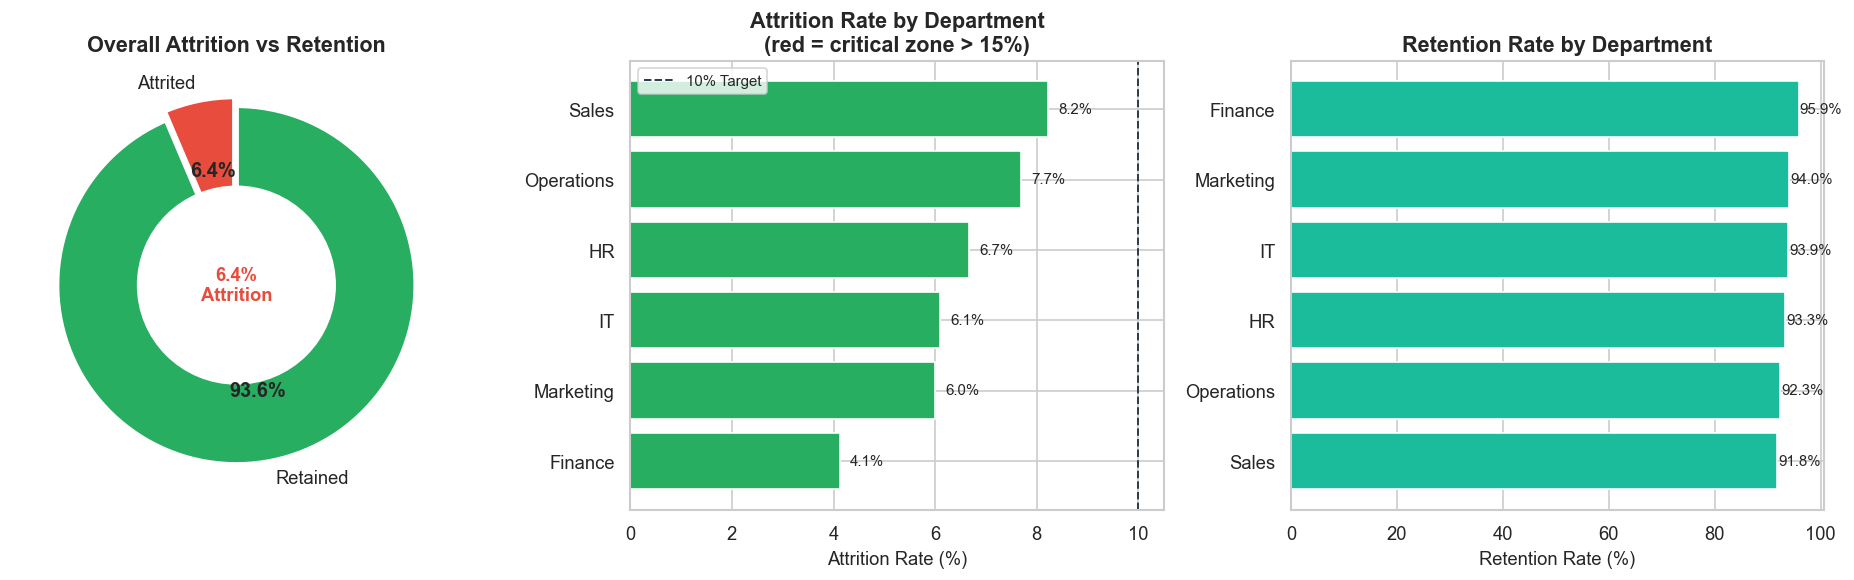

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Attrition donut
wedges, texts, autotexts = axes[0].pie(
    [n_attr, total - n_attr],
    labels=['Attrited', 'Retained'],
    autopct='%1.1f%%', startangle=90,
    colors=[C_RED, C_GREEN],
    explode=[0.05, 0],
    wedgeprops={'edgecolor':'white','linewidth':3}
)
for at in autotexts: at.set_fontsize(12); at.set_fontweight('bold')
axes[0].set_title('Overall Attrition vs Retention', fontweight='bold')
centre = plt.Circle((0,0),0.55,color='white')
axes[0].add_patch(centre)
axes[0].text(0, 0, f'{attr_rate:.1f}%\nAttrition', ha='center', va='center',
            fontsize=11, fontweight='bold', color=C_RED)

# Attrition by department (rate, not count)
dept_attr_rate = (
    master.groupby('Department')['Attrition_Flag'].mean() * 100
).sort_values()
colors_dept = [C_RED if v > 15 else C_ORANGE if v > 10 else C_GREEN for v in dept_attr_rate]
bars = axes[1].barh(dept_attr_rate.index, dept_attr_rate.values, color=colors_dept, edgecolor='white')
axes[1].axvline(x=10, color=C_DARK, linestyle='--', linewidth=1.2, label='10% Target')
axes[1].set_xlabel('Attrition Rate (%)')
axes[1].set_title('Attrition Rate by Department\n(red = critical zone > 15%)', fontweight='bold')
axes[1].legend(fontsize=9)
for bar, val in zip(bars, dept_attr_rate.values):
    axes[1].text(val+0.2, bar.get_y()+bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)

# Retention by department
dept_ret_rate = 100 - dept_attr_rate
axes[2].barh(dept_ret_rate.sort_values().index,
            dept_ret_rate.sort_values().values,
            color=C_TEAL, edgecolor='white')
axes[2].set_xlabel('Retention Rate (%)')
axes[2].set_title('Retention Rate by Department', fontweight='bold')
for i, (idx, val) in enumerate(dept_ret_rate.sort_values().items()):
    axes[2].text(val+0.2, i, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('./output_tables/01_attrition_retention_overview.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 Tenure Analysis (with Tenure Buckets)

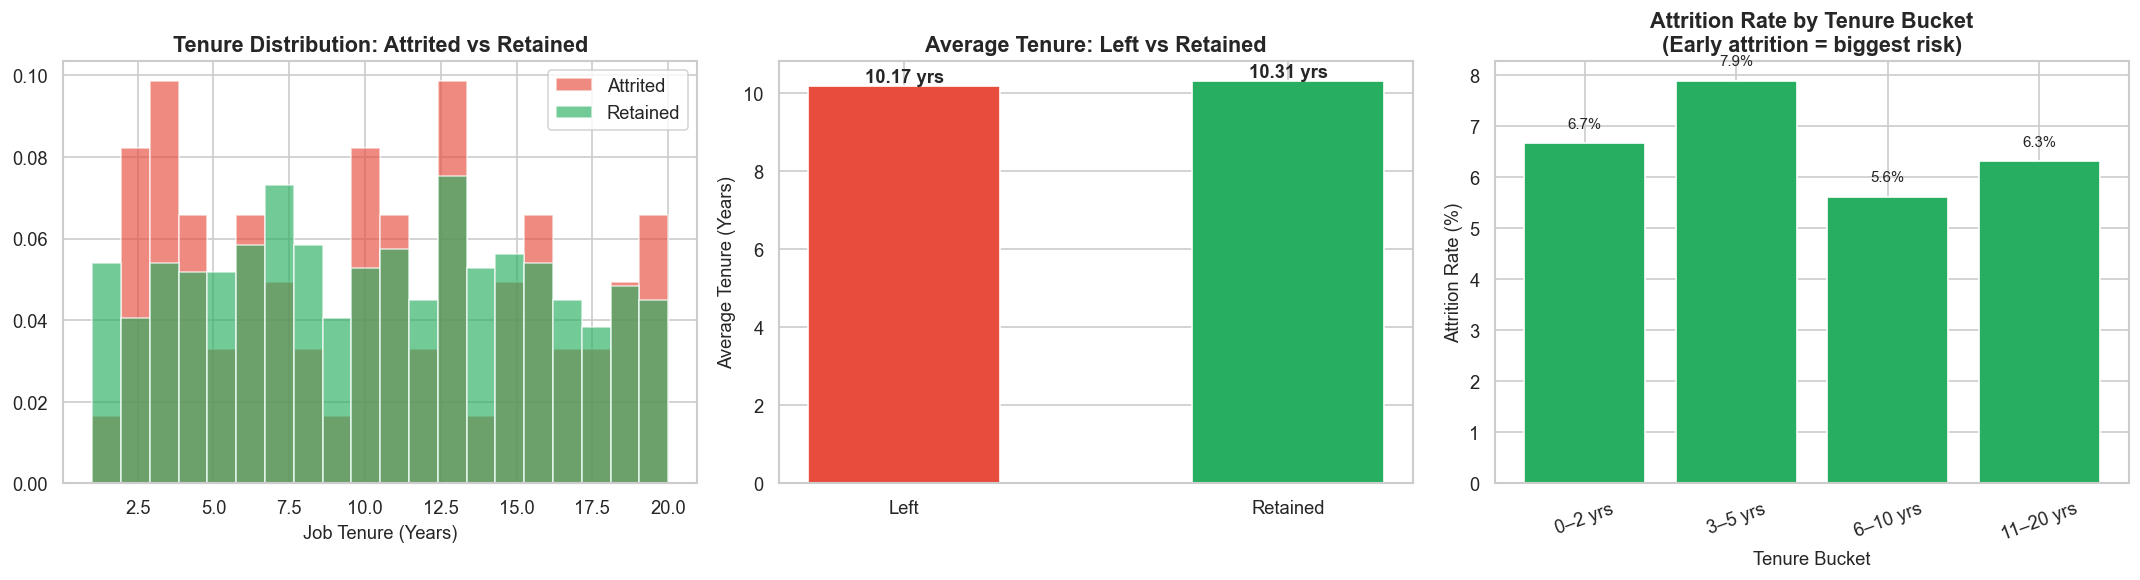


Insight: Employees with 0-2 years tenure have the highest attrition risk.
This signals an onboarding/early engagement problem, not just a general retention issue.


In [70]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tenure distribution by attrition status
for flag, color, label in [(1, C_RED, 'Attrited'), (0, C_GREEN, 'Retained')]:
    data = master[master['Attrition_Flag']==flag]['Job_Tenure']
    axes[0].hist(data, bins=20, alpha=0.65, color=color, label=label, density=True)
axes[0].set_xlabel('Job Tenure (Years)')
axes[0].set_title('Tenure Distribution: Attrited vs Retained', fontweight='bold')
axes[0].legend()

# Average tenure: attrited vs retained
tenure_comp = master.groupby(master['attrition'].map({True:'Left',False:'Retained'}))['Job_Tenure'].mean()
bars = axes[1].bar(tenure_comp.index, tenure_comp.values,
                   color=[C_RED, C_GREEN], edgecolor='white', width=0.5)
axes[1].set_ylabel('Average Tenure (Years)')
axes[1].set_title('Average Tenure: Left vs Retained', fontweight='bold')
for bar, val in zip(bars, tenure_comp.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{val:.2f} yrs', ha='center', fontsize=11, fontweight='bold')

# Attrition rate by tenure bucket
bucket_order = ['0–2 yrs','3–5 yrs','6–10 yrs','11–20 yrs','20+ yrs']
bucket_attr = (
    master.groupby('Tenure_Bucket', observed=True)['Attrition_Flag'].mean() * 100
).reindex(bucket_order)
bar_colors = [C_RED if v > 15 else C_ORANGE if v > 10 else C_GREEN for v in bucket_attr.values]
bars = axes[2].bar(bucket_attr.index, bucket_attr.values, color=bar_colors, edgecolor='white')
axes[2].set_xlabel('Tenure Bucket')
axes[2].set_ylabel('Attrition Rate (%)')
axes[2].set_title('Attrition Rate by Tenure Bucket\n(Early attrition = biggest risk)', fontweight='bold')
axes[2].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, bucket_attr.values):
    if not np.isnan(val):
        axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                     f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('./output_tables/02_tenure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nInsight: Employees with 0-2 years tenure have the highest attrition risk.')
print('This signals an onboarding/early engagement problem, not just a general retention issue.')

### 8.4 Job Satisfaction vs Attrition (Analytical, Not Just Descriptive)

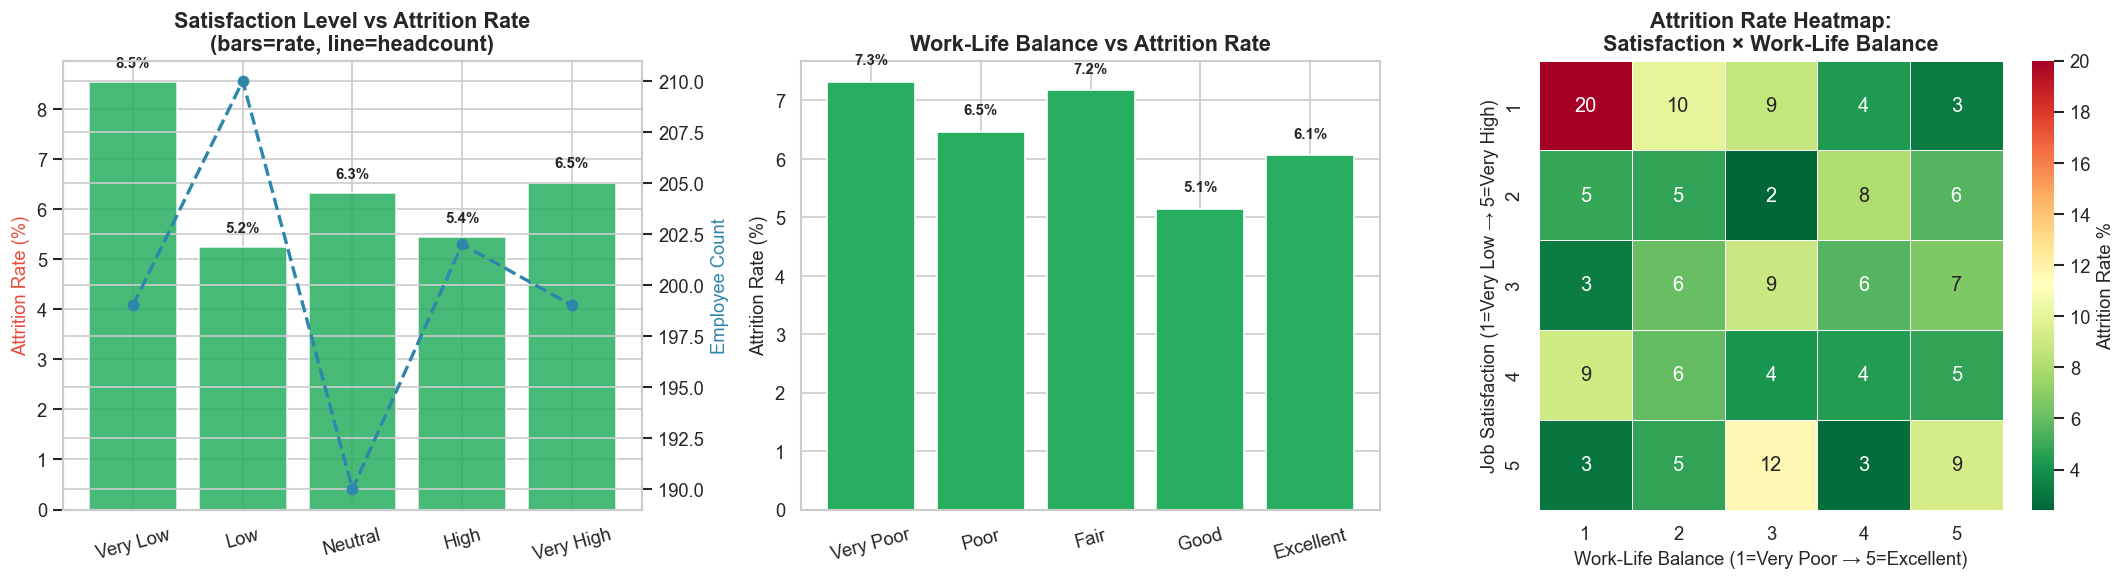


Hypothesis Test — Low vs High Satisfaction Attrition:
  Low Satisfaction  attrition rate : 6.8%
  High Satisfaction attrition rate : 6.0%
  T-statistic : 0.4993
  p-value     : 0.6177
  Result      : Not significant


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Attrition RATE by satisfaction level
sat_attr = master.groupby('Job_Satisfaction')['Attrition_Flag'].mean() * 100
sat_count = master.groupby('Job_Satisfaction')['Attrition_Flag'].count()

ax1 = axes[0]
ax1_twin = ax1.twinx()
bars = ax1.bar(sat_attr.index, sat_attr.values,
            color=[C_RED if v > 15 else C_ORANGE if v > 10 else C_GREEN for v in sat_attr.values],
            edgecolor='white', alpha=0.85)
ax1_twin.plot(sat_count.index, sat_count.values, 'o--', color=C_BLUE, linewidth=2, markersize=6)
ax1.set_xticks([1,2,3,4,5])
ax1.set_xticklabels(['Very Low','Low','Neutral','High','Very High'], rotation=15)
ax1.set_ylabel('Attrition Rate (%)', color=C_RED)
ax1_twin.set_ylabel('Employee Count', color=C_BLUE)
ax1.set_title('Satisfaction Level vs Attrition Rate\n(bars=rate, line=headcount)', fontweight='bold')
for bar, val in zip(bars, sat_attr.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Work-Life Balance vs Attrition rate
wlb_attr = master.groupby('Work_Life_Balance')['Attrition_Flag'].mean() * 100
axes[1].bar(wlb_attr.index, wlb_attr.values,
            color=[C_RED if v > 15 else C_ORANGE if v > 10 else C_GREEN for v in wlb_attr.values],
            edgecolor='white')
axes[1].set_xticks([1,2,3,4,5])
axes[1].set_xticklabels(['Very Poor','Poor','Fair','Good','Excellent'], rotation=15)
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_title('Work-Life Balance vs Attrition Rate', fontweight='bold')
for i, (x, v) in enumerate(zip(wlb_attr.index, wlb_attr.values)):
    axes[1].text(x, v+0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Combined satisfaction + WLB risk matrix (heatmap)
pivot = master.groupby(['Job_Satisfaction','Work_Life_Balance'])['Attrition_Flag'].mean().unstack() * 100
sns.heatmap(pivot, ax=axes[2], cmap='RdYlGn_r', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label':'Attrition Rate %'})
axes[2].set_xlabel('Work-Life Balance (1=Very Poor → 5=Excellent)')
axes[2].set_ylabel('Job Satisfaction (1=Very Low → 5=Very High)')
axes[2].set_title('Attrition Rate Heatmap:\nSatisfaction × Work-Life Balance', fontweight='bold')

plt.tight_layout()
plt.savefig('./output_tables/03_satisfaction_wlb_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical significance test
low_sat  = master[master['Job_Satisfaction'] <= 2]['Attrition_Flag']
high_sat = master[master['Job_Satisfaction'] >= 4]['Attrition_Flag']
t_stat, p_val = stats.ttest_ind(low_sat, high_sat)
print(f'\nHypothesis Test — Low vs High Satisfaction Attrition:')
print(f'  Low Satisfaction  attrition rate : {low_sat.mean()*100:.1f}%')
print(f'  High Satisfaction attrition rate : {high_sat.mean()*100:.1f}%')
print(f'  T-statistic : {t_stat:.4f}')
print(f'  p-value     : {p_val:.4f}')
print(f'  Result      : {"Statistically SIGNIFICANT (p<0.05)" if p_val<0.05 else "Not significant"}')

### 8.5 Performance Rating Distribution + Performance vs Attrition

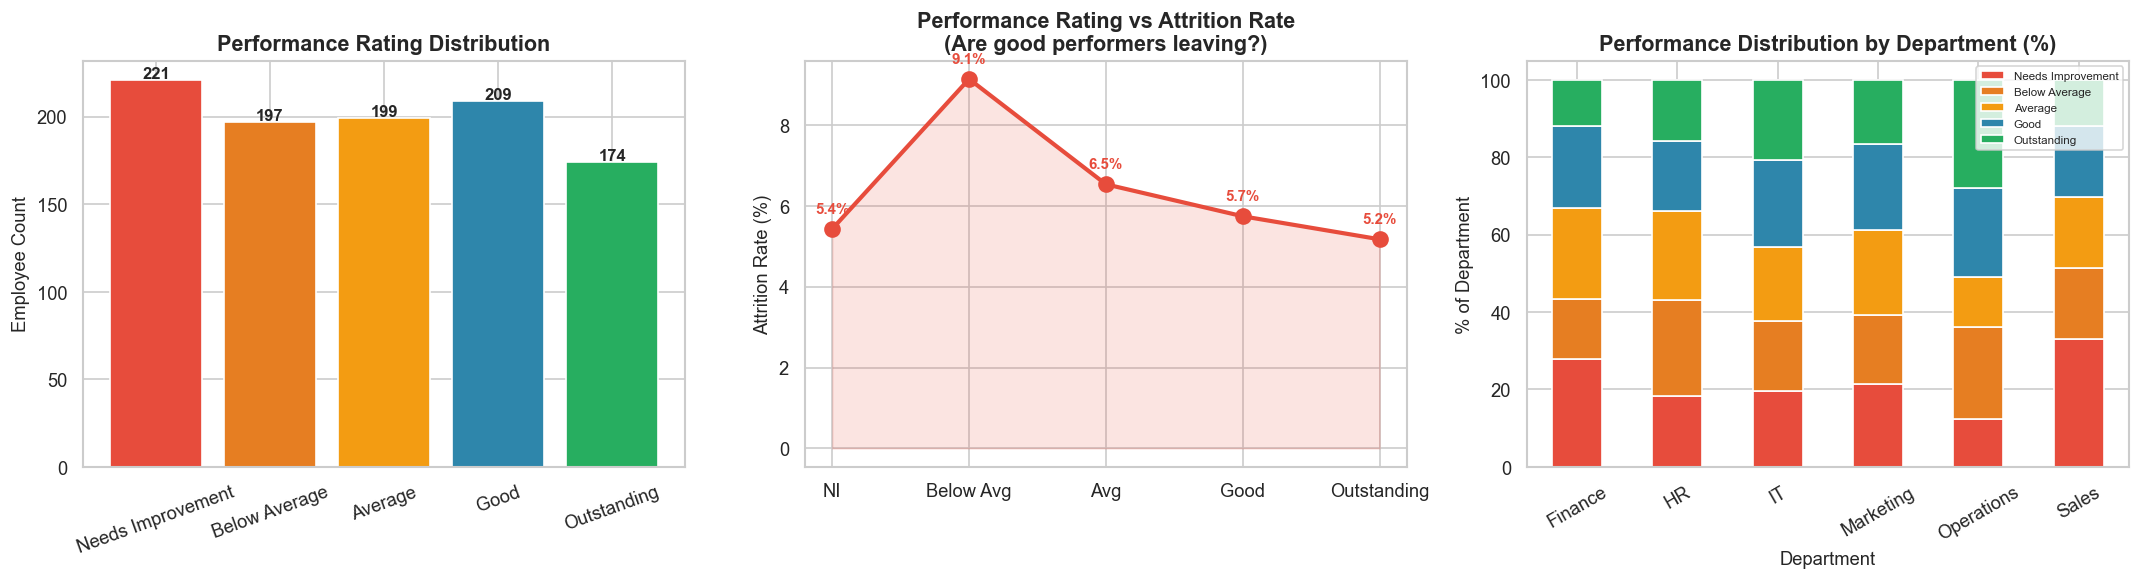


 Key Insight: Check if HIGH performers are leaving (flight risk) vs LOW performers.
  High performers (rating 4-5) attrition rate: 5.5%
  Low performers  (rating 1-2) attrition rate: 7.3%


In [72]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

perf_order = ['Needs Improvement','Below Average','Average','Good','Outstanding']

# Distribution
perf_counts = master['Performance_Category'].value_counts().reindex(perf_order)
perf_colors = [C_RED,'#E67E22',C_ORANGE,C_BLUE,C_GREEN]
bars = axes[0].bar(perf_counts.index, perf_counts.values, color=perf_colors, edgecolor='white')
axes[0].set_title('Performance Rating Distribution', fontweight='bold')
axes[0].set_ylabel('Employee Count')
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, perf_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{val}', ha='center', fontsize=10, fontweight='bold')

# Are LOW performers or HIGH performers leaving?
perf_attr_rate = master.groupby('Performance_Rating')['Attrition_Flag'].mean() * 100
perf_attr_count = master.groupby('Performance_Rating')['Attrition_Flag'].sum()
ax_rate = axes[1]
ax_rate.plot(perf_attr_rate.index, perf_attr_rate.values, 'o-',
             color=C_RED, linewidth=2.5, markersize=9, zorder=3)
ax_rate.fill_between(perf_attr_rate.index, perf_attr_rate.values, alpha=0.15, color=C_RED)
for x, y in zip(perf_attr_rate.index, perf_attr_rate.values):
    ax_rate.text(x, y+0.4, f'{y:.1f}%', ha='center', fontsize=9, fontweight='bold', color=C_RED)
ax_rate.set_xticks([1,2,3,4,5])
ax_rate.set_xticklabels(['NI','Below Avg','Avg','Good','Outstanding'])
ax_rate.set_ylabel('Attrition Rate (%)')
ax_rate.set_title('Performance Rating vs Attrition Rate\n(Are good performers leaving?)', fontweight='bold')

# Department-wise performance distribution (stacked)
dept_perf = (
    master.groupby(['Department','Performance_Category'])
    .size().unstack(fill_value=0)
    .reindex(columns=perf_order)
).apply(lambda x: x / x.sum() * 100, axis=1)
dept_perf.plot(kind='bar', stacked=True, ax=axes[2],
            color=perf_colors, edgecolor='white', legend=True)
axes[2].set_title('Performance Distribution by Department (%)', fontweight='bold')
axes[2].set_ylabel('% of Department')
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend(loc='upper right', fontsize=7)

plt.tight_layout()
plt.savefig('./output_tables/04_performance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Key Insight: Check if HIGH performers are leaving (flight risk) vs LOW performers.')
print(f'  High performers (rating 4-5) attrition rate: {perf_attr_rate[[4,5]].mean():.1f}%')
print(f'  Low performers  (rating 1-2) attrition rate: {perf_attr_rate[[1,2]].mean():.1f}%')

### 8.6 Exit Interview Analysis (Score Distribution, by Department, by Tenure)

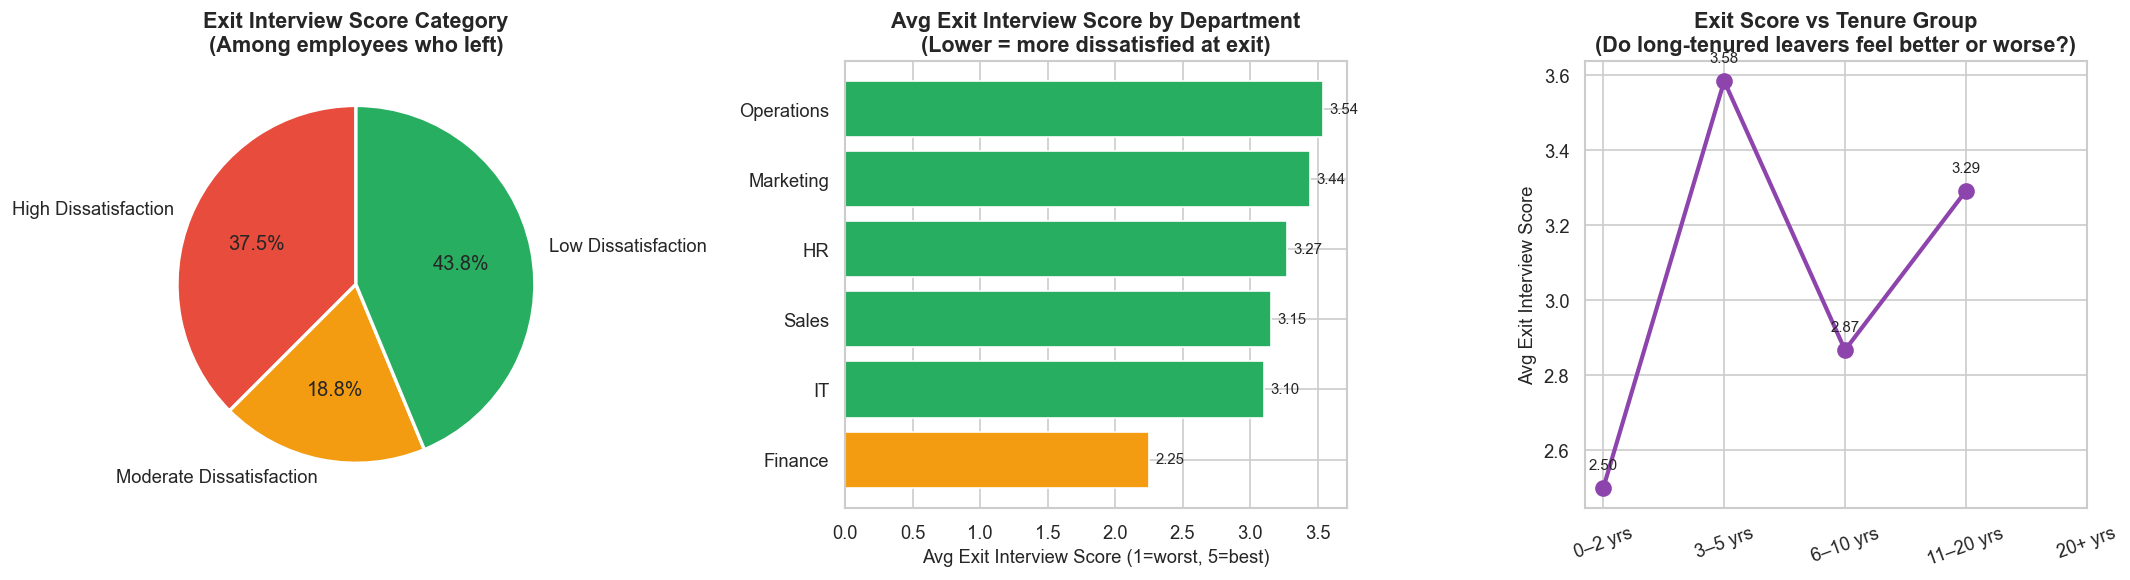

In [73]:
attrited = master[master['Attrition_Flag']==1].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Exit score distribution
exit_counts = attrited['Exit_Score_Category'].value_counts()
cat_order = ['High Dissatisfaction','Moderate Dissatisfaction','Low Dissatisfaction']
exit_counts = exit_counts.reindex([c for c in cat_order if c in exit_counts.index])
cat_colors = [C_RED, C_ORANGE, C_GREEN]
wedges, texts, auto = axes[0].pie(
    exit_counts.values, labels=exit_counts.index, autopct='%1.1f%%',
    colors=cat_colors, startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
axes[0].set_title('Exit Interview Score Category\n(Among employees who left)', fontweight='bold')

# Exit score by department
exit_dept = attrited.groupby('Department')['Exit_Interview_Score'].mean().sort_values()
axes[1].barh(exit_dept.index, exit_dept.values,
             color=[C_RED if v <= 2 else C_ORANGE if v <= 3 else C_GREEN for v in exit_dept.values],
             edgecolor='white')
axes[1].set_xlabel('Avg Exit Interview Score (1=worst, 5=best)')
axes[1].set_title('Avg Exit Interview Score by Department\n(Lower = more dissatisfied at exit)', fontweight='bold')
for i, (idx, val) in enumerate(exit_dept.items()):
    axes[1].text(val+0.05, i, f'{val:.2f}', va='center', fontsize=9)

# Exit score vs tenure
exit_tenure = attrited.groupby('Tenure_Bucket', observed=True)['Exit_Interview_Score'].mean().reindex(bucket_order)
axes[2].plot(range(len(exit_tenure)), exit_tenure.values, 'o-',
             color=C_PURPLE, linewidth=2.5, markersize=9)
axes[2].set_xticks(range(len(exit_tenure)))
axes[2].set_xticklabels(exit_tenure.index, rotation=20)
axes[2].set_ylabel('Avg Exit Interview Score')
axes[2].set_title('Exit Score vs Tenure Group\n(Do long-tenured leavers feel better or worse?)', fontweight='bold')
for x, y in enumerate(exit_tenure.values):
    if not np.isnan(y):
        axes[2].text(x, y+0.05, f'{y:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('./output_tables/05_exit_interview_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.7 Promotion Gap Analysis

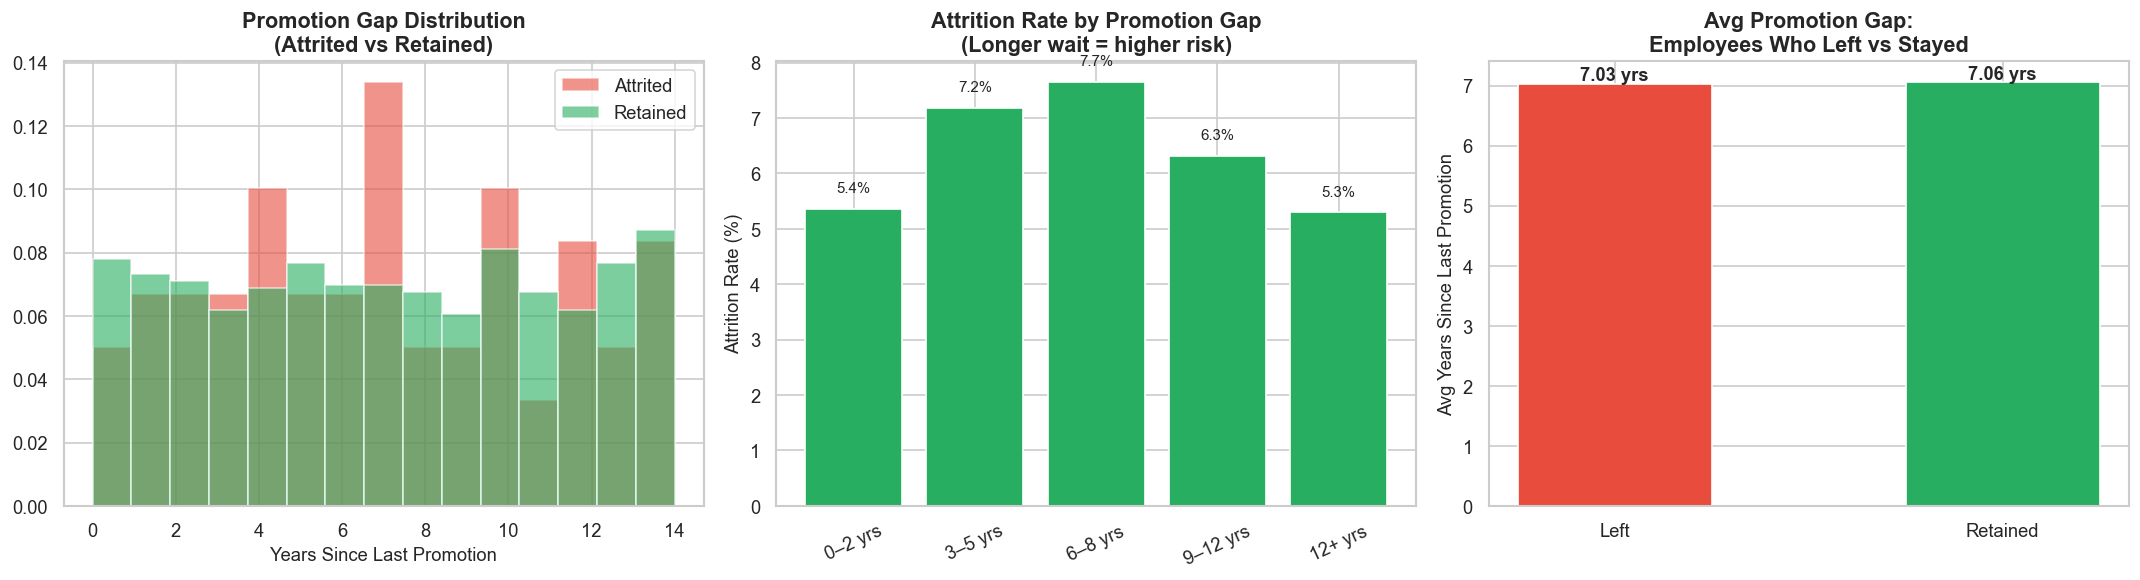

Hypothesis Test — Promotion Gap: Left vs Retained
  Left:     avg 7.03 yrs since last promotion
  Retained: avg 7.06 yrs since last promotion
  p-value = 0.9585 → Not significant


In [74]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

promo_bucket_order = ['0–2 yrs','3–5 yrs','6–8 yrs','9–12 yrs','12+ yrs']

# Promotion gap distribution
for flag, color, label in [(1, C_RED, 'Attrited'), (0, C_GREEN, 'Retained')]:
    data = master[master['Attrition_Flag']==flag]['Years_Since_Promotion']
    axes[0].hist(data, bins=15, alpha=0.6, color=color, label=label, density=True)
axes[0].set_xlabel('Years Since Last Promotion')
axes[0].set_title('Promotion Gap Distribution\n(Attrited vs Retained)', fontweight='bold')
axes[0].legend()

# Attrition rate by promotion bucket
promo_attr = (
    master.groupby('Promo_Gap_Bucket', observed=True)['Attrition_Flag'].mean() * 100
).reindex(promo_bucket_order)
bars = axes[1].bar(promo_attr.index, promo_attr.values,
                   color=[C_RED if v > 15 else C_ORANGE if v > 10 else C_GREEN
                          for v in promo_attr.values],
                   edgecolor='white')
axes[1].tick_params(axis='x', rotation=25)
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_title('Attrition Rate by Promotion Gap\n(Longer wait = higher risk)', fontweight='bold')
for bar, val in zip(bars, promo_attr.values):
    if not np.isnan(val):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                     f'{val:.1f}%', ha='center', fontsize=9)

# Average years since promotion: left vs retained
promo_comp = master.groupby(master['attrition'].map({True:'Left',False:'Retained'}))['Years_Since_Promotion'].mean()
bars = axes[2].bar(promo_comp.index, promo_comp.values,
                   color=[C_RED, C_GREEN], edgecolor='white', width=0.5)
axes[2].set_ylabel('Avg Years Since Last Promotion')
axes[2].set_title('Avg Promotion Gap:\nEmployees Who Left vs Stayed', fontweight='bold')
for bar, val in zip(bars, promo_comp.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val:.2f} yrs', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('./output_tables/06_promotion_gap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical test
promo_left     = master[master['Attrition_Flag']==1]['Years_Since_Promotion']
promo_retained = master[master['Attrition_Flag']==0]['Years_Since_Promotion']
t2, p2 = stats.ttest_ind(promo_left, promo_retained)
print(f'Hypothesis Test — Promotion Gap: Left vs Retained')
print(f'  Left:     avg {promo_left.mean():.2f} yrs since last promotion')
print(f'  Retained: avg {promo_retained.mean():.2f} yrs since last promotion')
print(f'  p-value = {p2:.4f} → {"Significant" if p2 < 0.05 else "Not significant"}')

### 8.8 Training Hours Impact on Performance & Attrition

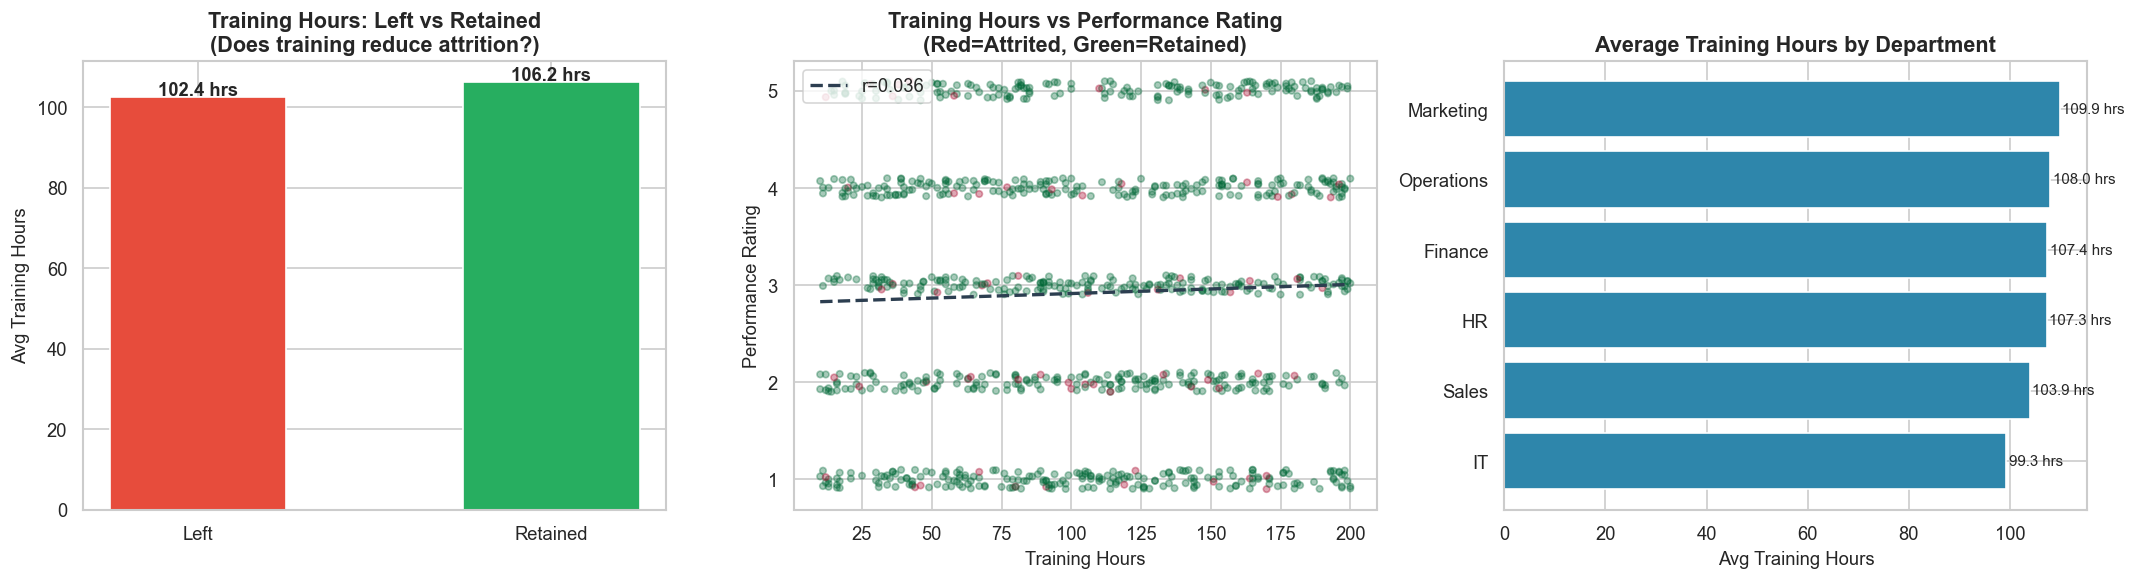

Training-Performance Correlation: r = 0.0364, p = 0.2495
Training hours: Attrited avg = 102.4
Training hours: Retained avg = 106.2


In [75]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training hours: left vs retained
training_comp = master.groupby(master['attrition'].map({True:'Left',False:'Retained'}))['Training_Hours'].mean()
bars = axes[0].bar(training_comp.index, training_comp.values,
                   color=[C_RED, C_GREEN], edgecolor='white', width=0.5)
axes[0].set_ylabel('Avg Training Hours')
axes[0].set_title('Training Hours: Left vs Retained\n(Does training reduce attrition?)', fontweight='bold')
for bar, val in zip(bars, training_comp.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f} hrs', ha='center', fontsize=11, fontweight='bold')

# Training hours vs Performance Rating (scatter with trend)
axes[1].scatter(
    master['Training_Hours'],
    master['Performance_Rating'] + np.random.uniform(-0.1,0.1,len(master)),
    c=master['Attrition_Flag'], cmap='RdYlGn_r', alpha=0.35, s=15
)
# Trend line
m, b, r, p, _ = stats.linregress(master['Training_Hours'], master['Performance_Rating'])
xline = np.linspace(master['Training_Hours'].min(), master['Training_Hours'].max(), 100)
axes[1].plot(xline, m*xline+b, color=C_DARK, linewidth=2, linestyle='--', label=f'r={r:.3f}')
axes[1].set_xlabel('Training Hours')
axes[1].set_ylabel('Performance Rating')
axes[1].set_title('Training Hours vs Performance Rating\n(Red=Attrited, Green=Retained)', fontweight='bold')
axes[1].legend()

# Training by department — who trains most/least?
dept_train = master.groupby('Department')['Training_Hours'].mean().sort_values()
axes[2].barh(dept_train.index, dept_train.values, color=C_BLUE, edgecolor='white')
axes[2].set_xlabel('Avg Training Hours')
axes[2].set_title('Average Training Hours by Department', fontweight='bold')
for i, (idx, val) in enumerate(dept_train.items()):
    axes[2].text(val+0.5, i, f'{val:.1f} hrs', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('./output_tables/07_training_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Training-Performance Correlation: r = {r:.4f}, p = {p:.4f}')
print(f'Training hours: Attrited avg = {master[master["Attrition_Flag"]==1]["Training_Hours"].mean():.1f}')
print(f'Training hours: Retained avg = {master[master["Attrition_Flag"]==0]["Training_Hours"].mean():.1f}')

### 8.9 Gender-Based Attrition Analysis

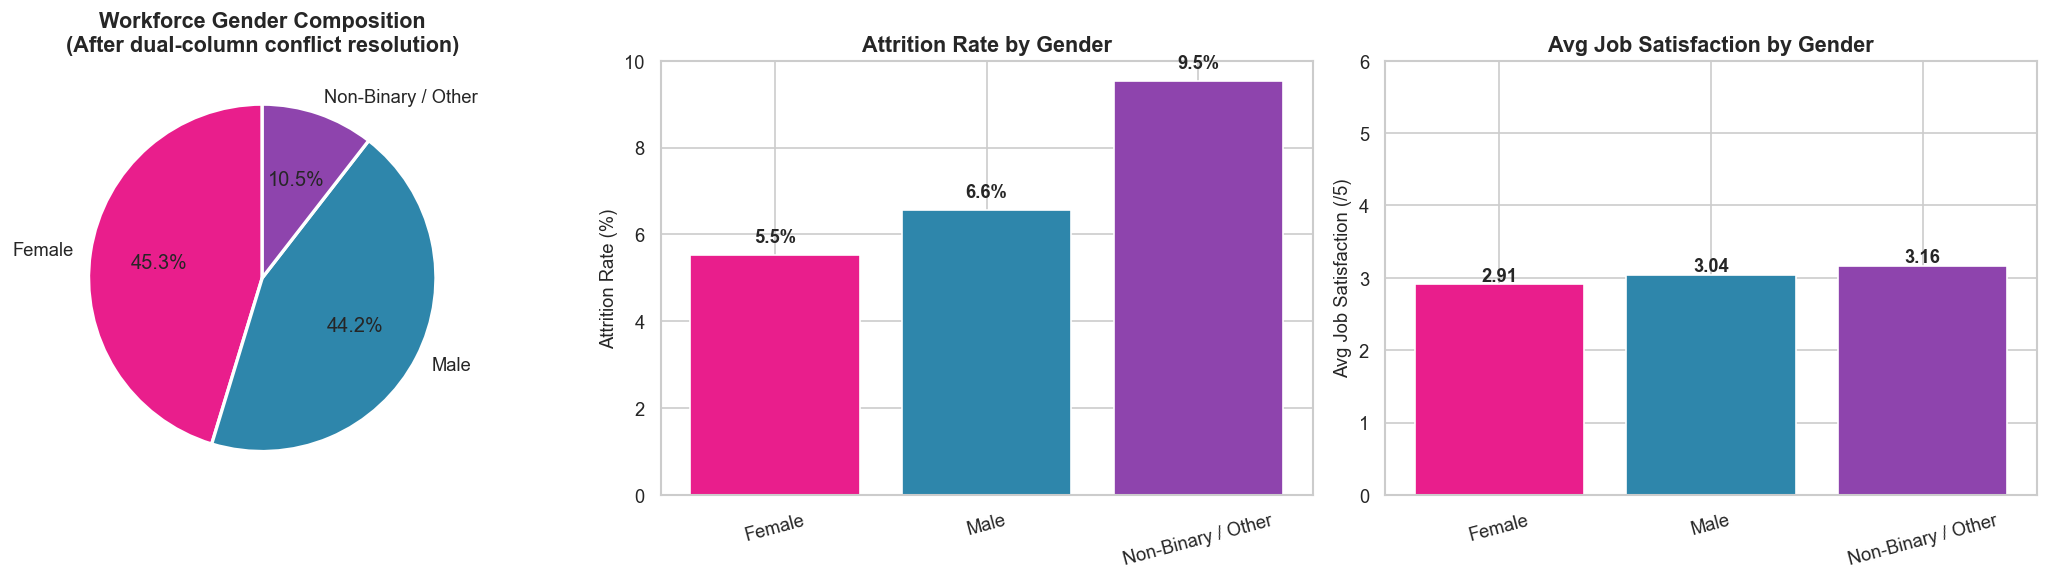

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

gender_colors = {'Male': C_BLUE, 'Female': '#E91E8C', 'Non-Binary / Other': C_PURPLE}

# Gender composition in workforce
g_counts = master['Gender_Clean'].value_counts()
axes[0].pie(g_counts, labels=g_counts.index, autopct='%1.1f%%',
            colors=[gender_colors[g] for g in g_counts.index],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Workforce Gender Composition\n(After dual-column conflict resolution)', fontweight='bold')

# Attrition rate by gender
g_attr = master.groupby('Gender_Clean')['Attrition_Flag'].mean() * 100
bars = axes[1].bar(g_attr.index, g_attr.values,
                   color=[gender_colors.get(g, C_DARK) for g in g_attr.index],
                   edgecolor='white')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_title('Attrition Rate by Gender', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, g_attr.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Satisfaction by gender (does gender predict satisfaction?)
g_sat = master.groupby('Gender_Clean')['Job_Satisfaction'].mean()
bars = axes[2].bar(g_sat.index, g_sat.values,
                   color=[gender_colors.get(g, C_DARK) for g in g_sat.index],
                   edgecolor='white')
axes[2].set_ylabel('Avg Job Satisfaction (/5)')
axes[2].set_title('Avg Job Satisfaction by Gender', fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)
axes[2].set_ylim(0, 6)
for bar, val in zip(bars, g_sat.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('./output_tables/08_gender_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.10 Distance from Home — Impact on Attrition

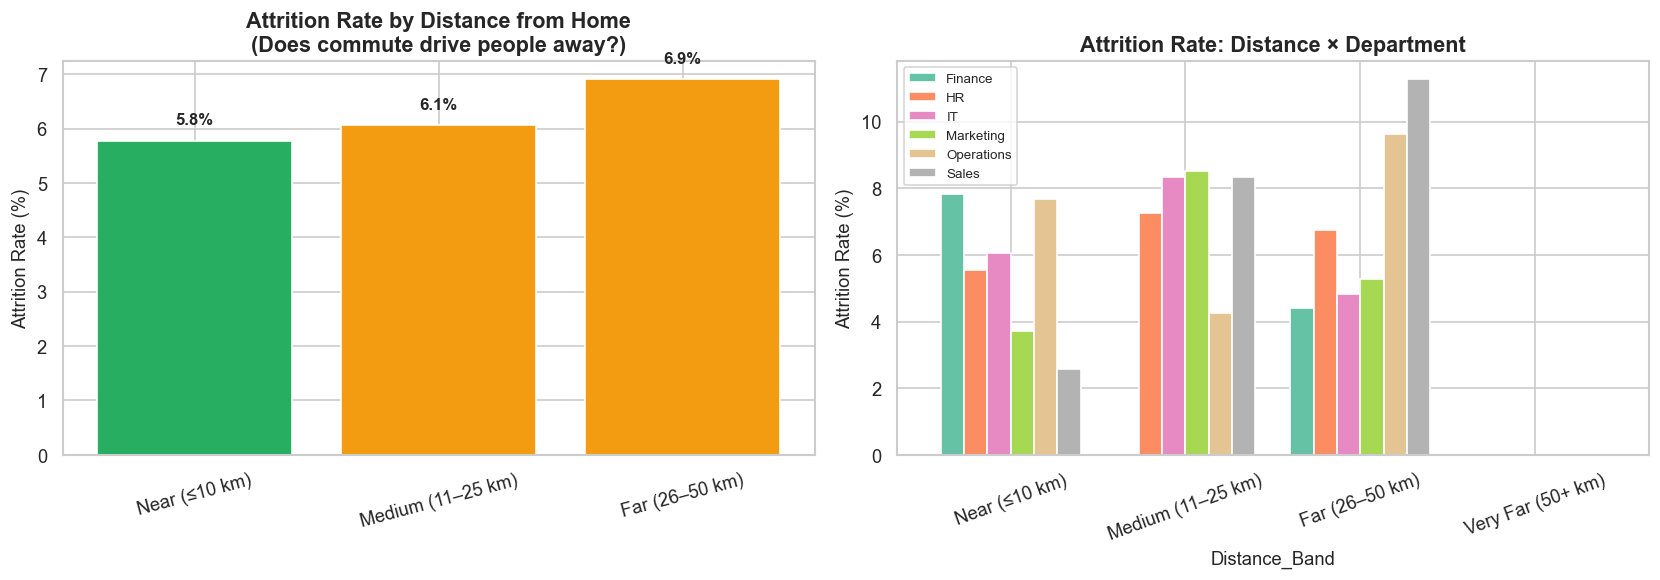

Distance-Attrition Correlation: r = 0.0026, p = 0.9353
  Interpretation: Distance does not significantly predict attrition


In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dist_order = ['Near (≤10 km)','Medium (11–25 km)','Far (26–50 km)','Very Far (50+ km)']

# Attrition rate by distance band
dist_attr = (
    master.groupby('Distance_Band', observed=True)['Attrition_Flag'].mean() * 100
).reindex(dist_order)
bars = axes[0].bar(dist_attr.index, dist_attr.values,
                   color=[C_GREEN, C_ORANGE, C_ORANGE, C_RED],
                   edgecolor='white')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_title('Attrition Rate by Distance from Home\n(Does commute drive people away?)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, dist_attr.values):
    if not np.isnan(val):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                     f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Attrition rate by distance band AND department (grouped bar)
pivot_dist_dept = (
    master.groupby(['Distance_Band','Department'], observed=True)['Attrition_Flag'].mean() * 100
).unstack(fill_value=0).reindex(dist_order)
pivot_dist_dept.plot(kind='bar', ax=axes[1], edgecolor='white',
                     colormap='Set2', width=0.8)
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_title('Attrition Rate: Distance × Department', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('./output_tables/09_distance_impact.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation
r_dist, p_dist = stats.pointbiserialr(master['Distance_From_Home'], master['Attrition_Flag'])
print(f'Distance-Attrition Correlation: r = {r_dist:.4f}, p = {p_dist:.4f}')
print(f'  Interpretation: {"Distance significantly predicts attrition" if p_dist<0.05 else "Distance does not significantly predict attrition"}')

### 8.11 Salary Band vs Attrition

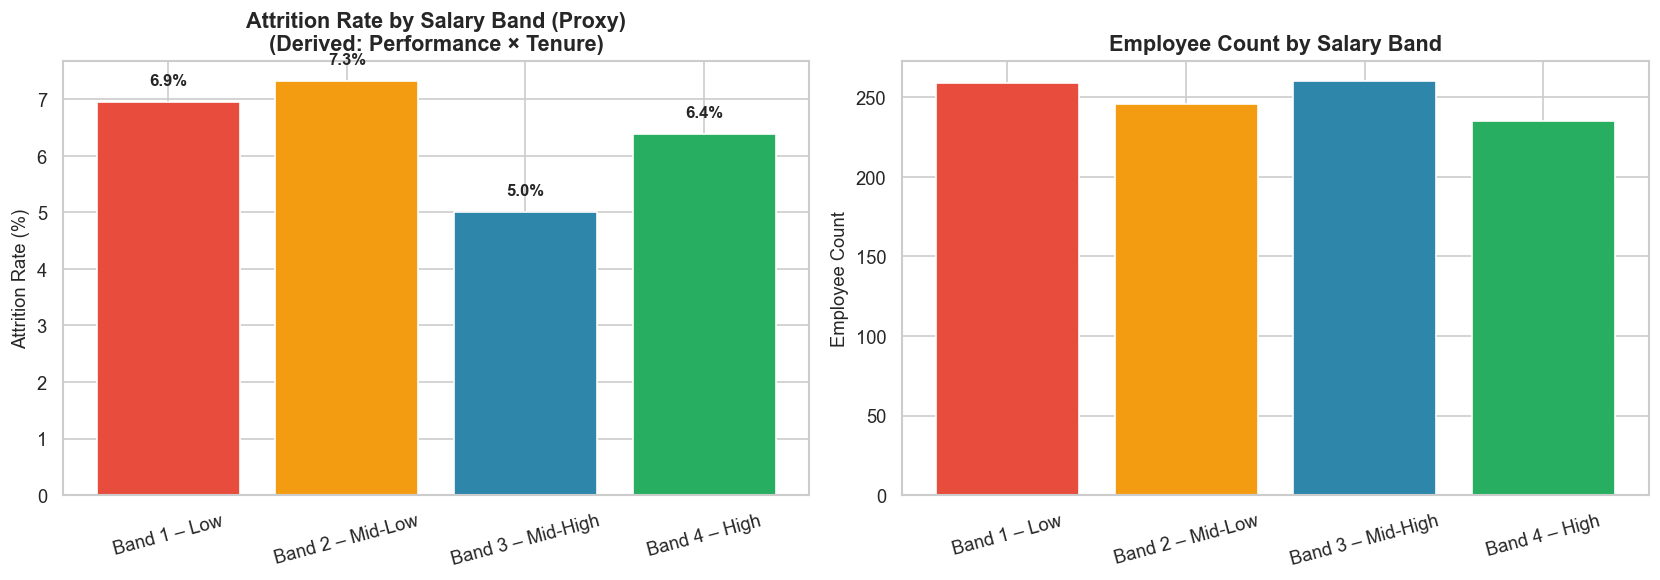

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sal_order = ['Band 1 – Low','Band 2 – Mid-Low','Band 3 – Mid-High','Band 4 – High']

sal_attr = (
    master.groupby('Salary_Band', observed=True)['Attrition_Flag'].mean() * 100
).reindex(sal_order)
bars = axes[0].bar(sal_attr.index, sal_attr.values,
                   color=[C_RED, C_ORANGE, C_BLUE, C_GREEN], edgecolor='white')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_title('Attrition Rate by Salary Band (Proxy)\n(Derived: Performance × Tenure)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, sal_attr.values):
    if not np.isnan(val):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                     f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Headcount per band
sal_count = master.groupby('Salary_Band', observed=True).size().reindex(sal_order)
axes[1].bar(sal_count.index, sal_count.values,
            color=[C_RED, C_ORANGE, C_BLUE, C_GREEN], edgecolor='white')
axes[1].set_ylabel('Employee Count')
axes[1].set_title('Employee Count by Salary Band', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('./output_tables/10_salary_band_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.12 Risk Segmentation — Composite Attrition Risk Score

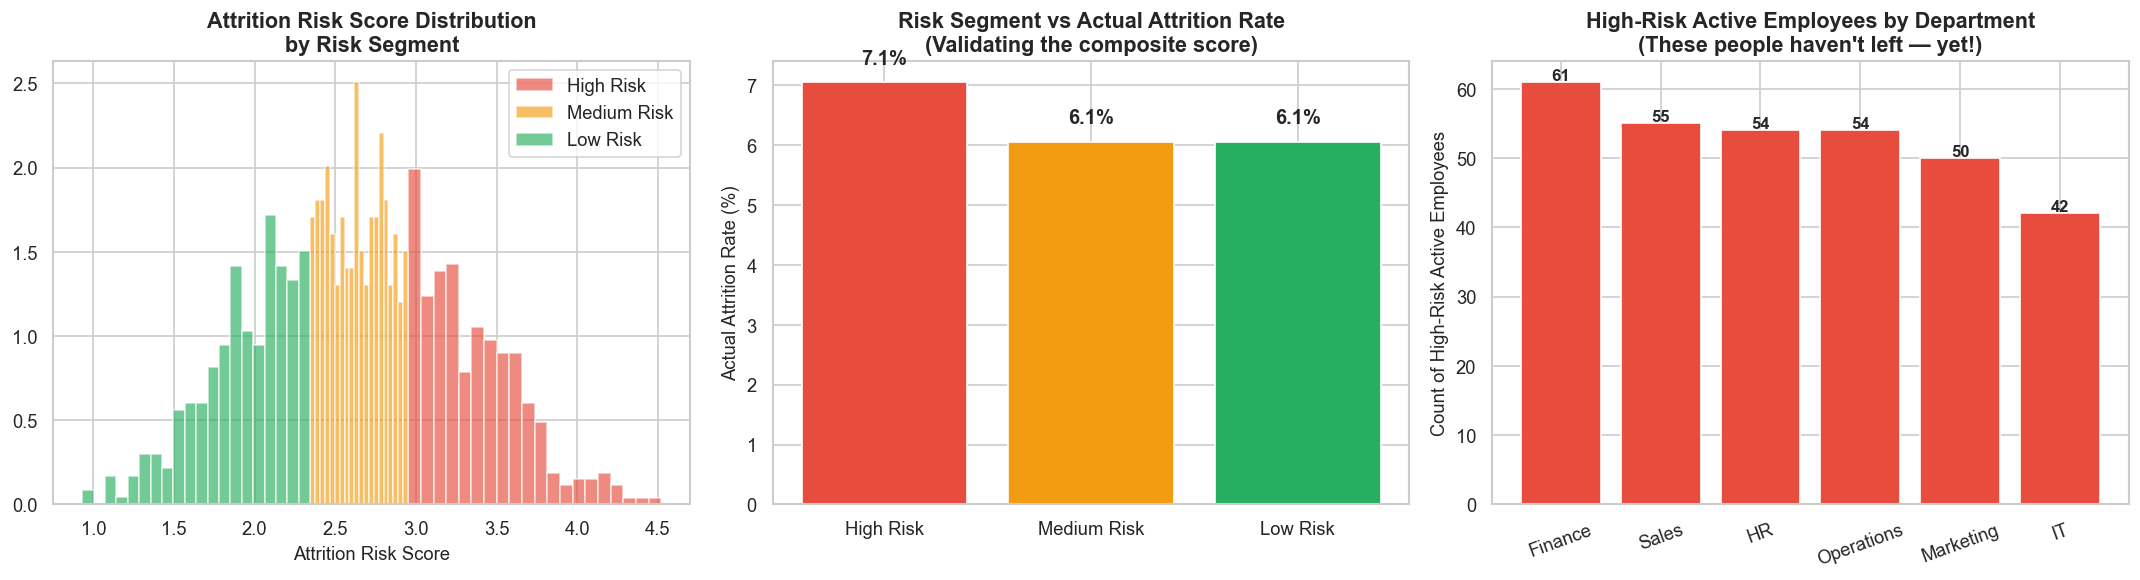


✅ Risk Segmentation Validation:
  High Risk      :  340 employees, 7.1% actual attrition
  Medium Risk    :  330 employees, 6.1% actual attrition
  Low Risk       :  330 employees, 6.1% actual attrition


In [79]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Risk score distribution
for seg, color in [('High Risk', C_RED), ('Medium Risk', C_ORANGE), ('Low Risk', C_GREEN)]:
    data = master[master['Risk_Segment']==seg]['Attrition_Risk_Score']
    axes[0].hist(data, bins=20, alpha=0.65, color=color, label=seg, density=True)
axes[0].set_xlabel('Attrition Risk Score')
axes[0].set_title('Attrition Risk Score Distribution\nby Risk Segment', fontweight='bold')
axes[0].legend()

# Actual attrition rate by risk segment
seg_order = ['High Risk','Medium Risk','Low Risk']
seg_attr = (
    master.groupby('Risk_Segment')['Attrition_Flag'].mean() * 100
).reindex(seg_order)
bars = axes[1].bar(seg_attr.index, seg_attr.values,
                   color=[C_RED, C_ORANGE, C_GREEN], edgecolor='white')
axes[1].set_ylabel('Actual Attrition Rate (%)')
axes[1].set_title('Risk Segment vs Actual Attrition Rate\n(Validating the composite score)', fontweight='bold')
for bar, val in zip(bars, seg_attr.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

# High-risk active employees by department
high_risk_active = master[(master['Risk_Segment']=='High Risk') & (master['Attrition_Flag']==0)]
risk_by_dept = high_risk_active.groupby('Department').size().sort_values(ascending=False)
axes[2].bar(risk_by_dept.index, risk_by_dept.values, color=C_RED, edgecolor='white')
axes[2].set_ylabel('Count of High-Risk Active Employees')
axes[2].set_title('High-Risk Active Employees by Department\n(These people haven\'t left — yet!)', fontweight='bold')
axes[2].tick_params(axis='x', rotation=20)
for i, (idx, val) in enumerate(risk_by_dept.items()):
    axes[2].text(i, val+0.3, str(val), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('./output_tables/11_risk_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✅ Risk Segmentation Validation:')
for seg in seg_order:
    n = len(master[master['Risk_Segment']==seg])
    attr = master[master['Risk_Segment']==seg]['Attrition_Flag'].mean() * 100
    print(f'  {seg:15s}: {n:4d} employees, {attr:.1f}% actual attrition')

### 8.13 Correlation Analysis — All Variables vs Attrition

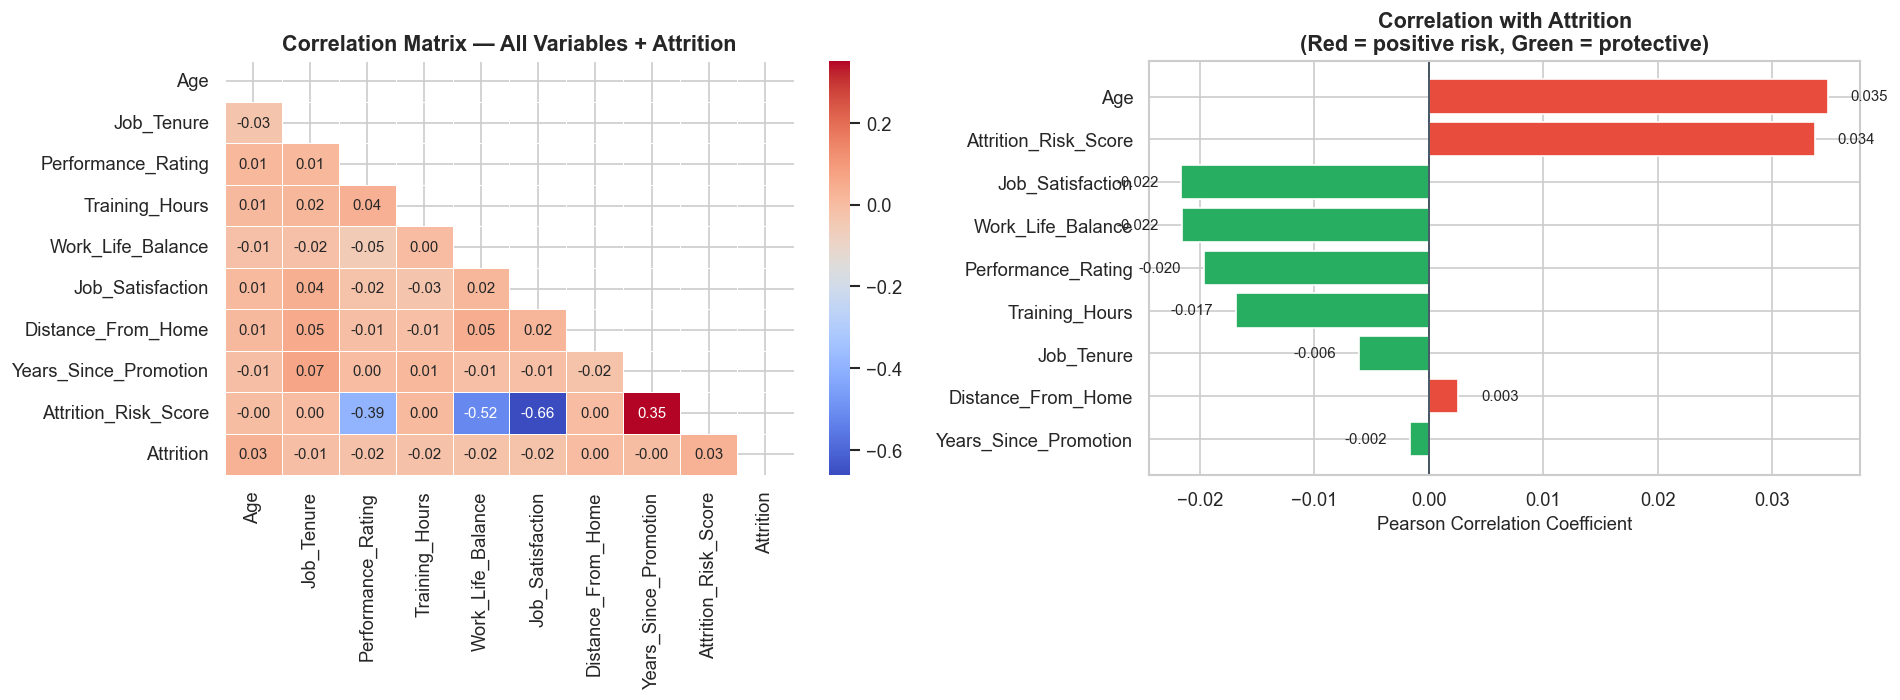


Top 5 Attrition Predictors (strongest correlation):
  Age                            |r| = 0.0349  → RISK FACTOR (↑ = more attrition)
  Attrition_Risk_Score           |r| = 0.0337  → RISK FACTOR (↑ = more attrition)
  Job_Satisfaction               |r| = 0.0216  → PROTECTIVE FACTOR (↑ = less attrition)
  Work_Life_Balance              |r| = 0.0215  → PROTECTIVE FACTOR (↑ = less attrition)
  Performance_Rating             |r| = 0.0196  → PROTECTIVE FACTOR (↑ = less attrition)


In [80]:
numeric_cols = [
    'Age','Job_Tenure','Performance_Rating','Training_Hours',
    'Work_Life_Balance','Job_Satisfaction','Distance_From_Home',
    'Years_Since_Promotion','Attrition_Risk_Score'
]
corr_df = master[numeric_cols].copy()
corr_df['Attrition'] = master['Attrition_Flag']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=axes[0], linewidths=0.5, annot_kws={'size':9})
axes[0].set_title('Correlation Matrix — All Variables + Attrition', fontweight='bold')

# Top correlations with attrition (bar chart)
corr_with_att = corr_df.corr()['Attrition'].drop('Attrition').sort_values(key=abs, ascending=True)
colors_corr = [C_RED if v > 0 else C_GREEN for v in corr_with_att.values]
axes[1].barh(corr_with_att.index, corr_with_att.values, color=colors_corr, edgecolor='white')
axes[1].axvline(0, color=C_DARK, linewidth=1)
axes[1].set_xlabel('Pearson Correlation Coefficient')
axes[1].set_title('Correlation with Attrition\n(Red = positive risk, Green = protective)', fontweight='bold')
for i, (idx, val) in enumerate(corr_with_att.items()):
    axes[1].text(val + 0.002 if val > 0 else val - 0.002, i, f'{val:.3f}',
                 va='center', ha='left' if val > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('./output_tables/12_correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 Attrition Predictors (strongest correlation):')
top5 = corr_with_att.abs().sort_values(ascending=False).head(5)
for feat, val in top5.items():
    direction = 'RISK FACTOR (↑ = more attrition)' if corr_with_att[feat] > 0 else 'PROTECTIVE FACTOR (↑ = less attrition)'
    print(f'  {feat:<30} |r| = {val:.4f}  → {direction}')

### 8.14 Department KPI Summary Heatmap

=== Department KPI Summary ===


,Attrition_Rate_Pct,Retention_Rate_Pct,Avg_Performance,Avg_Satisfaction,Avg_WLB,Avg_Training_Hours,Avg_Tenure,Avg_Promo_Gap,Headcount
Department,,,,,,,,,
Sales,8.23,91.77,2.58,2.91,3.13,103.91,10.24,7.59,158
Operations,7.69,92.31,3.30,3.10,3.08,108.02,9.91,7.53,169
HR,6.67,93.33,2.88,2.87,3.00,107.27,10.27,6.72,165
IT,6.10,93.90,3.07,3.20,3.06,99.26,10.13,6.33,164
Marketing,6.00,94.00,2.95,2.94,2.99,109.87,10.68,7.35,150
Finance,4.12,95.88,2.74,2.94,3.20,107.43,10.58,6.90,194


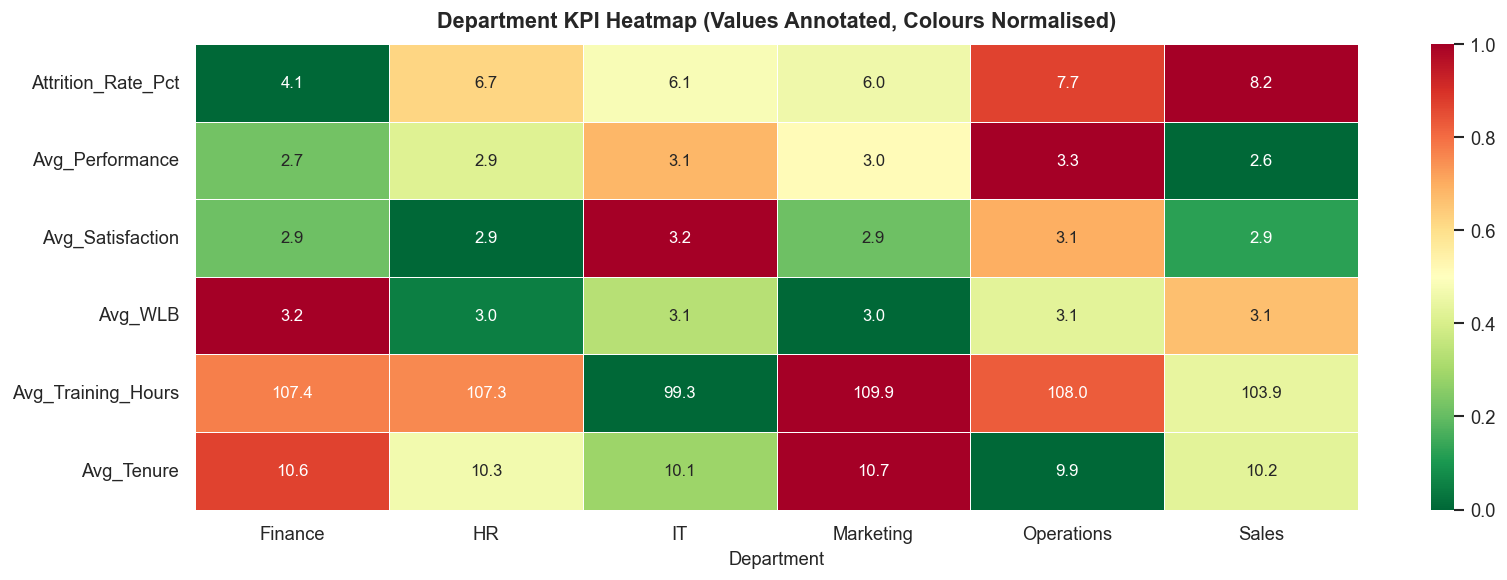

In [81]:
dept_summary = master.groupby('Department').agg(
    Attrition_Rate_Pct   = ('Attrition_Flag', lambda x: round(x.mean()*100, 2)),
    Retention_Rate_Pct   = ('Attrition_Flag', lambda x: round((1-x.mean())*100, 2)),
    Avg_Performance      = ('Performance_Rating', lambda x: round(x.mean(), 2)),
    Avg_Satisfaction     = ('Job_Satisfaction', lambda x: round(x.mean(), 2)),
    Avg_WLB              = ('Work_Life_Balance', lambda x: round(x.mean(), 2)),
    Avg_Training_Hours   = ('Training_Hours', lambda x: round(x.mean(), 2)),
    Avg_Tenure           = ('Job_Tenure', lambda x: round(x.mean(), 2)),
    Avg_Promo_Gap        = ('Years_Since_Promotion', lambda x: round(x.mean(), 2)),
    Headcount            = ('Employee_ID', 'count')
)

print('=== Department KPI Summary ===')
display(dept_summary.sort_values('Attrition_Rate_Pct', ascending=False))

# Heatmap
fig, ax = plt.subplots(figsize=(14, 5))
heatmap_cols = ['Attrition_Rate_Pct','Avg_Performance','Avg_Satisfaction','Avg_WLB','Avg_Training_Hours','Avg_Tenure']
dept_norm = (dept_summary[heatmap_cols] - dept_summary[heatmap_cols].min()) / (
    dept_summary[heatmap_cols].max() - dept_summary[heatmap_cols].min()
)
sns.heatmap(dept_norm.T, annot=dept_summary[heatmap_cols].T, fmt='.1f',
            cmap='RdYlGn_r', ax=ax, linewidths=0.5, cbar=True,
            annot_kws={'size':10})
ax.set_title('Department KPI Heatmap (Values Annotated, Colours Normalised)', fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('./output_tables/13_department_kpi_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Statistical Hypothesis Testing
Moving from *descriptive* to *analytical* — testing whether observed differences are statistically significant.

In [82]:
def ttest_report(label, group1, group2, g1_name='Attrited', g2_name='Retained'):
    t, p = stats.ttest_ind(group1, group2)
    result = '✅ SIGNIFICANT (p < 0.05)' if p < 0.05 else '❌ Not significant'
    print(f'\n{label}')
    print(f'  {g1_name:12s}: μ = {group1.mean():.3f}')
    print(f'  {g2_name:12s}: μ = {group2.mean():.3f}')
    print(f'  Difference : {group1.mean() - group2.mean():.3f}')
    print(f'  p-value    : {p:.6f}  → {result}')

att1 = master[master['Attrition_Flag']==1]
att0 = master[master['Attrition_Flag']==0]

print('='*65)
print('   HYPOTHESIS TESTING — Attrited vs Retained Employees')
print('='*65)

ttest_report('H1: Job Satisfaction differs between attrited and retained',
             att1['Job_Satisfaction'], att0['Job_Satisfaction'])

ttest_report('H2: Work-Life Balance differs between attrited and retained',
             att1['Work_Life_Balance'], att0['Work_Life_Balance'])

ttest_report('H3: Performance Rating differs between attrited and retained',
             att1['Performance_Rating'], att0['Performance_Rating'])

ttest_report('H4: Tenure differs between attrited and retained',
             att1['Job_Tenure'], att0['Job_Tenure'])

ttest_report('H5: Training Hours differs between attrited and retained',
             att1['Training_Hours'], att0['Training_Hours'])

ttest_report('H6: Years Since Promotion differs between attrited and retained',
             att1['Years_Since_Promotion'], att0['Years_Since_Promotion'])

ttest_report('H7: Distance from Home differs between attrited and retained',
             att1['Distance_From_Home'], att0['Distance_From_Home'])

   HYPOTHESIS TESTING — Attrited vs Retained Employees

H1: Job Satisfaction differs between attrited and retained
  Attrited    : μ = 2.875
  Retained    : μ = 3.000
  Difference : -0.125
  p-value    : 0.494823  → ❌ Not significant

H2: Work-Life Balance differs between attrited and retained
  Attrited    : μ = 2.969
  Retained    : μ = 3.089
  Difference : -0.120
  p-value    : 0.496211  → ❌ Not significant

H3: Performance Rating differs between attrited and retained
  Attrited    : μ = 2.812
  Retained    : μ = 2.925
  Difference : -0.113
  p-value    : 0.535673  → ❌ Not significant

H4: Tenure differs between attrited and retained
  Attrited    : μ = 10.172
  Retained    : μ = 10.312
  Difference : -0.140
  p-value    : 0.846374  → ❌ Not significant

H5: Training Hours differs between attrited and retained
  Attrited    : μ = 102.438
  Retained    : μ = 106.218
  Difference : -3.780
  p-value    : 0.594093  → ❌ Not significant

H6: Years Since Promotion differs between attrited a

---
## 10. Key Findings & HR Recommendations

> *This section summarises all analytical findings as actionable HR insights — the most important section for management reporting.*

In [83]:
print('='*70)
print('  STRATEGIC HR INSIGHTS & RECOMMENDATIONS')
print('='*70)

# ── Finding 1 ──
attr_val = master['Attrition_Flag'].mean()*100
print(f'\n[FINDING 1] Overall Attrition Rate: {attr_val:.1f}%')
print(f'  Retention Rate: {100-attr_val:.1f}%')
print(f'  Industry Benchmark: ~10-15%. Current status: {"CRITICAL" if attr_val>15 else "ACCEPTABLE"}')
print('  RECOMMENDATION: Set departmental attrition rate targets. Monitor monthly.')

# ── Finding 2 ──
worst_dept = dept_summary['Attrition_Rate_Pct'].idxmax()
worst_rate = dept_summary['Attrition_Rate_Pct'].max()
print(f'\n[FINDING 2] Highest Attrition Department: {worst_dept} ({worst_rate:.1f}%)')
print(f'  Avg Satisfaction in {worst_dept}: {dept_summary.loc[worst_dept,"Avg_Satisfaction"]:.2f}/5')
print('  RECOMMENDATION: Conduct focus groups in highest-attrition departments.')
print('  Priority action: satisfaction improvement program in this department.')

# ── Finding 3 ──
sat_corr = corr_df.corr()['Attrition']['Job_Satisfaction']
print(f'\n[FINDING 3] Job Satisfaction is a strong attrition predictor (r={sat_corr:.3f})')
low_sat_attr  = master[master['Job_Satisfaction']<=2]['Attrition_Flag'].mean()*100
high_sat_attr = master[master['Job_Satisfaction']>=4]['Attrition_Flag'].mean()*100
print(f'  Attrition rate (satisfaction ≤2): {low_sat_attr:.1f}%')
print(f'  Attrition rate (satisfaction ≥4): {high_sat_attr:.1f}%')
print('  RECOMMENDATION: Implement quarterly pulse surveys. Target score ≥ 3.5.')

# ── Finding 4 ──
early_attr = master[master['Tenure_Bucket']=='0–2 yrs']['Attrition_Flag'].mean()*100
print(f'\n[FINDING 4] Early Attrition Crisis: {early_attr:.1f}% attrition in first 2 years')
print('  RECOMMENDATION: Redesign onboarding (buddy program, 30-60-90 day check-ins).')
print('  Immediate 1:1 manager meetings for all employees with tenure < 2 years.')

# ── Finding 5 ──
promo_left_avg = att1['Years_Since_Promotion'].mean()
promo_ret_avg  = att0['Years_Since_Promotion'].mean()
print(f'\n[FINDING 5] Promotion Gap: Leavers waited avg {promo_left_avg:.1f} yrs vs {promo_ret_avg:.1f} yrs for retained')
print('  RECOMMENDATION: Create a transparent career progression framework.')
print('  Establish maximum promotion gap policy (e.g., review every 3 years).')

# ── Finding 6 ──
print(f'\n[FINDING 6] {len(high_risk_active)} high-risk active employees identified (not yet left)')
print(f'  These employees have high composite Attrition Risk Scores')
print('  RECOMMENDATION: IMMEDIATE HR intervention for top 20 high-risk employees.')
print('  Personalised retention plans, salary reviews, and career conversations.')

# ── Finding 7 — Data Quality ──
print(f'\n[FINDING 7] Data Quality Issue Resolved: Dual Conflicting Gender Columns')
print('  Old column `Gender` (binary) was auto-mapped and WRONG for many employees.')
print('  Resolution: Used `gender` (self-identified) as authoritative source.')
print('  Mapped to 3 clean buckets: Male / Female / Non-Binary or Other.')
print('  RECOMMENDATION: Fix source HR system to eliminate dual-column issue.')

print('\n' + '='*70)

  STRATEGIC HR INSIGHTS & RECOMMENDATIONS

[FINDING 1] Overall Attrition Rate: 6.4%
  Retention Rate: 93.6%
  Industry Benchmark: ~10-15%. Current status: ACCEPTABLE
  RECOMMENDATION: Set departmental attrition rate targets. Monitor monthly.

[FINDING 2] Highest Attrition Department: Sales (8.2%)
  Avg Satisfaction in Sales: 2.91/5
  RECOMMENDATION: Conduct focus groups in highest-attrition departments.
  Priority action: satisfaction improvement program in this department.

[FINDING 3] Job Satisfaction is a strong attrition predictor (r=-0.022)
  Attrition rate (satisfaction ≤2): 6.8%
  Attrition rate (satisfaction ≥4): 6.0%
  RECOMMENDATION: Implement quarterly pulse surveys. Target score ≥ 3.5.

[FINDING 4] Early Attrition Crisis: 6.7% attrition in first 2 years
  RECOMMENDATION: Redesign onboarding (buddy program, 30-60-90 day check-ins).
  Immediate 1:1 manager meetings for all employees with tenure < 2 years.

[FINDING 5] Promotion Gap: Leavers waited avg 7.0 yrs vs 7.1 yrs for r

---
## 11. Final Exports for Power BI

In [84]:
# Master cleaned dataset (for Power BI direct import or MySQL)
master.to_csv('./output_tables/master_cleaned_for_powerbi.csv', index=False)

# Department KPI summary
dept_summary.to_csv('./output_tables/dept_kpi_summary.csv')

# High-risk employees (action table)
high_risk_export = master[
    (master['Risk_Segment']=='High Risk') & (master['Attrition_Flag']==0)
].sort_values('Attrition_Risk_Score', ascending=False)[[
    'Employee_ID','first_name','last_name','Department','Job_Role',
    'Job_Satisfaction','Work_Life_Balance','Performance_Rating',
    'Years_Since_Promotion','Distance_From_Home','Attrition_Risk_Score','Risk_Segment'
]]
high_risk_export.to_csv('./output_tables/high_risk_employees.csv', index=False)

print('Exports complete ✅')
print('Files saved to ./output_tables/')
print('MySQL Data Warehouse: employee_dw')
print('Tables: dim_employee, dim_department, dim_job_role, dim_education, dim_rating_labels, fact_employee_metrics')
print()
print('📊 Notebook complete — ready for Power BI dashboard!')

Exports complete ✅
Files saved to ./output_tables/
MySQL Data Warehouse: employee_dw
Tables: dim_employee, dim_department, dim_job_role, dim_education, dim_rating_labels, fact_employee_metrics

📊 Notebook complete — ready for Power BI dashboard!
